Pontificia Universidad Católica de Chile <br>
Facultad de Matemática <br>
Departamento de Estadística <br>
EYP2307 - Análisis de Regresión

---
<center>
    <h2>Proyecto EYP230I: Magnitud de eventos sísmicos USGS 2024</h2>
</center>

---


In [1]:
# Librerías utilizadas y configuración reproducible
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import importlib.metadata as md
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Markdown
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

def find_final_dir() -> Path:
    """Ubica Final/ al ejecutar desde esa carpeta o desde la raíz del proyecto."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "Final"] + [parent / "Final" for parent in cwd.parents]
    for candidate in candidates:
        if (candidate / "usgs_earthquakes_2024_mag4_raw.csv").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró usgs_earthquakes_2024_mag4_raw.csv en Final/ ni en la carpeta actual."
    )

FINAL_DIR = find_final_dir()
PROJECT_DIR = FINAL_DIR.parent
RAW_DATA_PATH = FINAL_DIR / "usgs_earthquakes_2024_mag4_raw.csv"
MODEL_READY_PATH = FINAL_DIR / "usgs_earthquakes_2024_mag4_model_ready.csv"
OUTPUT_DIR = FINAL_DIR / "outputs"
OUTPUT_FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = FINAL_DIR / "Plantilla_informe"
REPORT_FIG_DIR = REPORT_DIR / "figures"
REPORT_TABLE_DIR = REPORT_DIR / "tables"

for output_path in [OUTPUT_FIG_DIR, OUTPUT_TABLE_DIR, REPORT_FIG_DIR, REPORT_TABLE_DIR]:
    output_path.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de trabajo detectada: {FINAL_DIR.relative_to(PROJECT_DIR)}")
print(f"Archivo de datos: {RAW_DATA_PATH.relative_to(PROJECT_DIR)}")


Carpeta de trabajo detectada: Final
Archivo de datos: Final\usgs_earthquakes_2024_mag4_raw.csv


## Índice

1. [Introducción y planteamiento del problema](#1-introducción-y-planteamiento-del-problema)
2. [Preparación y tratamiento de datos](#2-preparación-y-tratamiento-de-datos)
3. [Análisis exploratorio de datos](#3-análisis-exploratorio-de-datos)
4. [Modelos preliminares y diagnóstico de M4](#4-modelos-preliminares-y-diagnóstico-de-m4)
5. [Desarrollo, selección y validación del modelo final](#5-desarrollo-selección-y-validación-del-modelo-final)
6. [Reproducibilidad](#6-reproducibilidad)
7. [Referencias](#7-referencias)

## 1. Introducción y Planteamiento del Problema


Este notebook desarrolla el informe final del proyecto de Análisis de Regresión con el **USGS Earthquake Catalog**, catálogo oficial del **U.S. Geological Survey**. La unidad de observación es un evento sísmico registrado durante 2024 y la muestra se restringe, por decisión metodológica, a eventos con magnitud al menos 4.

- **Variable respuesta:** magnitud reportada del evento (`mag`).
- **Enfoque:** descriptivo-explicativo, centrado en asociaciones promedio dentro de la muestra.
- **Alcance:** los resultados no se extrapolan a sismos menores ni constituyen predicción operacional.


### 1.1. Contexto y motivación


El catálogo USGS reúne mediciones estandarizadas sobre localización, profundidad, magnitud y características técnicas del registro de cada evento. Esta información permite estudiar si la magnitud reportada presenta diferencias promedio asociadas con atributos geográficos y con la forma en que el evento fue observado y codificado. El objetivo no es anticipar terremotos ni atribuir mecanismos causales, sino construir una explicación estadística ordenada de la variación observada en el catálogo 2024.


### 1.2. Pregunta de investigación y objetivo

En base al contexto anterior, se plantea la siguiente pregunta de investigación:

- **Pregunta de investigación:** ¿Cómo se asocia la magnitud de los eventos sísmicos registrados por USGS durante 2024 con su profundidad, localización geográfica y características técnicas del registro?

El objetivo no es predecir terremotos futuros ni construir un sistema operacional de alerta. El análisis busca describir asociaciones entre la magnitud reportada y variables observadas del catálogo, con herramientas de regresión lineal múltiple, inferencia y diagnóstico. Además, la muestra está truncada a eventos con `mag >= 4`; por lo tanto, las conclusiones no se extrapolan a sismos menores ni al proceso sísmico completo.

### 1.3. Aspectos éticos y uso de la fuente

Los datos provienen de una fuente oficial y pública, y no contienen datos personales. El riesgo ético directo es bajo. Aun así, el uso responsable exige no presentar este trabajo como predicción operacional de terremotos, sistema de alerta o recomendación de seguridad pública. Las conclusiones se deben formular como asociaciones estadísticas dentro del catálogo USGS 2024 con magnitud al menos 4, reconociendo sus limitaciones de cobertura, codificación y truncamiento.


## 2. Preparación y tratamiento de Datos


### 2.1. Configuración reproducible y carga de datos


Se usan librerías estándar para manipulación de datos, visualización, regresión lineal e inferencia. Las rutas se construyen con `pathlib` para que el notebook funcione al ejecutarse desde la carpeta `Final/` o desde la raíz del proyecto.


In [2]:
# Verificación temprana de rutas y carpetas de salida
assert RAW_DATA_PATH.exists(), f"No existe el archivo de datos: {RAW_DATA_PATH}"
for output_path in [OUTPUT_FIG_DIR, OUTPUT_TABLE_DIR, REPORT_FIG_DIR, REPORT_TABLE_DIR]:
    assert output_path.exists()
print(f"Lectura y salidas configuradas dentro de: {FINAL_DIR.relative_to(PROJECT_DIR)}")


Lectura y salidas configuradas dentro de: Final


La base se lee directamente desde el archivo crudo. Primero se revisan dimensiones, nombres de columnas y tipos de datos. Si alguna columna esperada no está disponible, se reporta la ausencia y el resto del flujo continúa con las variables presentes.


In [3]:
df_raw = pd.read_csv(RAW_DATA_PATH)

required_columns = [
    "mag", "depth", "latitude", "longitude", "nst", "gap", "dmin", "rms",
    "magType", "net", "place", "time", "id"
]
missing_required = [col for col in required_columns if col not in df_raw.columns]
available_required = [col for col in required_columns if col in df_raw.columns]

print(f"Dimensiones de la base cruda: {df_raw.shape[0]:,} filas x {df_raw.shape[1]:,} columnas")
print("Columnas disponibles:")
print(list(df_raw.columns))
if missing_required:
    print("\nColumnas esperadas ausentes:", missing_required)
else:
    print("\nTodas las columnas principales esperadas están disponibles.")

print("\nTipos de datos originales:")
display(df_raw.dtypes.rename("tipo").to_frame())

print("\nPrimeras filas:")
display(df_raw.head())


Dimensiones de la base cruda: 14,176 filas x 22 columnas
Columnas disponibles:
['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']

Todas las columnas principales esperadas están disponibles.

Tipos de datos originales:


,tipo
time,object
latitude,float64
longitude,float64
depth,float64
mag,float64
magType,object
nst,float64
gap,float64
dmin,float64
rms,float64



Primeras filas:


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2024-01-01T00:37:09.096Z,17.6625,145.4596,384.941,4.7,mb,198.0,36.0,2.429,0.50,...,2024-03-09T21:38:09.040Z,"272 km N of Saipan, Northern Mariana Islands",earthquake,10.13,5.448,0.042,168.0,reviewed,us,us
1,2024-01-01T00:54:44.947Z,-57.3045,-25.8967,55.881,4.4,mb,18.0,107.0,6.694,0.54,...,2024-03-09T21:40:15.040Z,South Sandwich Islands region,earthquake,8.65,8.639,0.156,12.0,reviewed,us,us
2,2024-01-01T00:59:19.656Z,-6.8599,107.1224,178.051,4.1,mb,43.0,97.0,0.490,0.67,...,2024-03-09T21:38:11.040Z,"4 km SSW of Cianjur, Indonesia",earthquake,6.71,5.273,0.102,26.0,reviewed,us,us
3,2024-01-01T01:05:25.000Z,-25.3436,-70.5175,35.000,4.3,mb,19.0,178.0,0.804,0.62,...,2024-03-09T21:38:10.040Z,"7 km NNW of Taltal, Chile",earthquake,3.99,1.966,0.239,5.0,reviewed,us,us
4,2024-01-01T01:43:14.869Z,-24.4120,179.8704,513.317,4.6,mb,89.0,31.0,5.199,0.71,...,2024-03-09T21:38:11.040Z,south of the Fiji Islands,earthquake,10.66,0.841,0.044,154.0,reviewed,us,us


### 2.2. Diccionario de variables


In [4]:
# Funciones auxiliares para mantener el formato en informe en Latex
def latex_escape(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value)
    replacements = {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$", "#": r"\#",
        "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}", "^": r"\textasciicircum{}"
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

def write_latex_tabular(df_table: pd.DataFrame, path: Path, column_format: str | None = None, index: bool = False):
    latex = df_table.to_latex(index=index, escape=True, column_format=column_format, bold_rows=False, float_format=lambda x: f"{x:.3f}")
    path.write_text(latex, encoding="utf-8")

def write_tabularx_two_col(rows, path: Path, first_col="Campo", second_col="Descripción"):
    row_end = r" \\"
    lines = [
        r"\begin{tabularx}{\textwidth}{@{}p{0.27\textwidth}X@{}}",
        r"\toprule",
        f"{latex_escape(first_col)} & {latex_escape(second_col)}{row_end}",
        r"\midrule",
    ]
    for left, right in rows:
        lines.append(f"{latex_escape(left)} & {latex_escape(right)}{row_end}")
    lines += [r"\bottomrule", r"\end{tabularx}"]
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

La siguiente tabla explicita los tres grupos conceptuales de predictores, sus variables y la razón por la cual se consideran. La selección no depende solo de correlaciones bivariadas: combina conexión con la pregunta, interpretabilidad dentro del catálogo y disponibilidad de datos. La tabla se guarda en CSV y LaTeX para mantener trazabilidad con el informe.


In [5]:
grupos_rows = [
    (
        "1. Características geofísicas y espaciales",
        "depth, depth², latitude, longitude",
        "Describen profundidad y ubicación; log_depth_plus_1 se conserva como sensibilidad, no como predictor final.",
    ),
    (
        "2. Características técnicas del registro",
        "log1p(nst), log1p(gap), log1p(dmin), rms",
        "Resumen cobertura, geometría, proximidad y ajuste; sus escalas se seleccionan mediante comparaciones justificadas.",
    ),
    (
        "3. Controles de codificación del catálogo",
        "magType_grouped, net_grouped",
        "Permiten estimar diferencias promedio por método de magnitud y red reportante mediante indicadores k-1.",
    ),
]

grupos_df = pd.DataFrame(
    grupos_rows,
    columns=["Grupo conceptual", "Variables incluidas", "Justificación metodológica"],
)
grupos_df.to_csv(REPORT_TABLE_DIR / "grupos_conceptuales.csv", index=False)
grupos_df.to_csv(OUTPUT_TABLE_DIR / "grupos_conceptuales.csv", index=False)
write_latex_tabular(grupos_df, REPORT_TABLE_DIR / "grupos_conceptuales.tex", column_format="lll")
display(grupos_df)


,Grupo conceptual,Variables incluidas,Justificación metodológica
0,1. Características geofísicas y espaciales,"depth, depth², latitude, longitude",Describen profundidad y ubicación; log_depth_p...
1,2. Características técnicas del registro,"log1p(nst), log1p(gap), log1p(dmin), rms","Resumen cobertura, geometría, proximidad y aju..."
2,3. Controles de codificación del catálogo,"magType_grouped, net_grouped",Permiten estimar diferencias promedio por méto...


La siguiente tabla resume el rol de las variables principales. La tabla se guarda en CSV y en formato LaTeX para el informe.


In [6]:
dictionary_rows = [
    ("mag", "Numérica continua", "Magnitud reportada del evento sísmico.", "Variable respuesta."),
    ("depth", "Numérica continua", "Profundidad del evento, usualmente en kilómetros según catálogo USGS.", "Predictor final en escala original, con término lineal y cuadrático."),
    ("log_depth_plus_1", "Numérica transformada", "log(depth + 1), calculado como log1p(depth.clip(lower=0)).", "Especificación candidata y análisis de sensibilidad; no se adopta en el modelo final."),
    ("latitude", "Numérica continua", "Latitud del epicentro.", "Localización geográfica."),
    ("longitude", "Numérica continua", "Longitud del epicentro.", "Localización geográfica."),
    ("nst", "Numérica discreta", "Número de estaciones usadas en la solución del evento.", "Característica técnica; el modelo final usa log1p(nst)."),
    ("gap", "Numérica continua", "Brecha azimutal de cobertura de estaciones.", "Característica técnica; el modelo final usa log1p(gap) y su cuadrado."),
    ("dmin", "Numérica continua", "Distancia mínima a una estación reportante.", "Característica técnica; el modelo final usa log1p(dmin) y su cuadrado."),
    ("rms", "Numérica continua", "Error RMS del ajuste del evento.", "Característica técnica conservada en su escala original."),
    ("month", "Numérica discreta", "Mes UTC del evento derivado desde time.", "Control temporal descriptivo."),
    ("hour", "Numérica discreta", "Hora UTC del evento derivada desde time.", "Control temporal descriptivo."),
    ("magType", "Categórica", "Tipo de magnitud reportada.", "Diferencias sistemáticas por escala de magnitud."),
    ("net", "Categórica", "Red u organismo que reporta el evento.", "Diferencias sistemáticas por red de reporte."),
    ("region_from_place", "Categórica derivada", "Región aproximada extraída desde el texto place.", "Resumen geográfico categórico."),
    ("place", "Texto", "Descripción textual del lugar del evento.", "Contexto y construcción de región."),
    ("time", "Fecha-hora", "Fecha y hora UTC del evento.", "Filtro temporal y variables derivadas."),
    ("id", "Identificador", "Identificador único del evento en el catálogo.", "Control de duplicados."),
]

dictionary_df = pd.DataFrame(dictionary_rows, columns=["variable", "tipo", "descripción", "uso en el análisis"])
dictionary_df.to_csv(REPORT_TABLE_DIR / "diccionario_variables.csv", index=False)
dictionary_df.to_csv(OUTPUT_TABLE_DIR / "diccionario_variables.csv", index=False)
write_latex_tabular(dictionary_df, REPORT_TABLE_DIR / "diccionario_variables.tex", column_format="llll")
display(dictionary_df)


,variable,tipo,descripción,uso en el análisis
0,mag,Numérica continua,Magnitud reportada del evento sísmico.,Variable respuesta.
1,depth,Numérica continua,"Profundidad del evento, usualmente en kilómetr...","Predictor final en escala original, con términ..."
2,log_depth_plus_1,Numérica transformada,"log(depth + 1), calculado como log1p(depth.cli...",Especificación candidata y análisis de sensibi...
3,latitude,Numérica continua,Latitud del epicentro.,Localización geográfica.
4,longitude,Numérica continua,Longitud del epicentro.,Localización geográfica.
5,nst,Numérica discreta,Número de estaciones usadas en la solución del...,Característica técnica; el modelo final usa lo...
6,gap,Numérica continua,Brecha azimutal de cobertura de estaciones.,Característica técnica; el modelo final usa lo...
7,dmin,Numérica continua,Distancia mínima a una estación reportante.,Característica técnica; el modelo final usa lo...
8,rms,Numérica continua,Error RMS del ajuste del evento.,Característica técnica conservada en su escala...
9,month,Numérica discreta,Mes UTC del evento derivado desde time.,Control temporal descriptivo.


### 2.3. Conversión de tipos y creación de variables

Se convierte `time` a fecha-hora UTC y las variables numéricas relevantes se fuerzan a tipo numérico con `errors="coerce"`. También se crean variables temporales (`month`, `hour`, `weekday`), la transformación `log_depth_plus_1` y una región aproximada desde `place`. Para `region_from_place`, si el texto tiene coma se conserva lo que aparece después de la última coma; si no tiene coma, se marca como `Unknown/No comma`.

La variable `log_depth_plus_1 = log1p(depth.clip(lower=0))` se crea como **especificación candidata**, no como decisión automática. El logaritmo puede representar cambios marginales decrecientes y reducir la asimetría de `depth`, pero la asimetría del predictor por sí sola no obliga a transformarlo: MCO requiere una media condicional bien especificada, no predictores normales. En la modelación final se compara, sobre la misma muestra, `depth`, `depth + depth²`, `log1p(depth)` y `log1p(depth) + [log1p(depth)]²`, usando ajuste, pruebas anidadas, validación y colinealidad.

Existe una profundidad levemente negativa (-0.07 km). Como `depth + 1 > 0`, `log1p(depth)` es matemáticamente posible; el recorte a cero se conserva como versión operacional solicitada y se contrasta con la versión sin recorte para verificar que esa única observación no determine la conclusión.

In [7]:
df = df_raw.copy()

numeric_columns = ["mag", "depth", "latitude", "longitude", "nst", "gap", "dmin", "rms"]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
    df["month"] = df["time"].dt.month
    df["hour"] = df["time"].dt.hour
    df["weekday"] = df["time"].dt.day_name()
else:
    df["month"] = np.nan
    df["hour"] = np.nan
    df["weekday"] = np.nan

if "depth" in df.columns:
    df["log_depth_plus_1"] = np.log1p(df["depth"].clip(lower=0))
else:
    df["log_depth_plus_1"] = np.nan

if "place" in df.columns:
    place = df["place"].astype("string")
    df["region_from_place"] = np.where(
        place.isna(),
        pd.NA,
        np.where(place.str.contains(",", regex=False, na=False), place.str.split(",").str[-1].str.strip(), "Unknown/No comma")
    )
    df["region_from_place"] = pd.Series(df["region_from_place"], index=df.index, dtype="string")
else:
    df["region_from_place"] = pd.Series(pd.NA, index=df.index, dtype="string")

created_columns = ["month", "hour", "weekday", "log_depth_plus_1", "region_from_place"]
print("Variables creadas:", created_columns)
display(df[available_required + [c for c in created_columns if c in df.columns]].head())


Variables creadas: ['month', 'hour', 'weekday', 'log_depth_plus_1', 'region_from_place']


,mag,depth,latitude,longitude,nst,gap,dmin,rms,magType,net,place,time,id,month,hour,weekday,log_depth_plus_1,region_from_place
0,4.7,384.941,17.6625,145.4596,198.0,36.0,2.429,0.50,mb,us,"272 km N of Saipan, Northern Mariana Islands",2024-01-01 00:37:09.096000+00:00,us6000m0w6,1,0,Monday,5.955685,Northern Mariana Islands
1,4.4,55.881,-57.3045,-25.8967,18.0,107.0,6.694,0.54,mb,us,South Sandwich Islands region,2024-01-01 00:54:44.947000+00:00,us6000m357,1,0,Monday,4.040961,Unknown/No comma
2,4.1,178.051,-6.8599,107.1224,43.0,97.0,0.490,0.67,mb,us,"4 km SSW of Cianjur, Indonesia",2024-01-01 00:59:19.656000+00:00,us6000m0wb,1,0,Monday,5.187671,Indonesia
3,4.3,35.000,-25.3436,-70.5175,19.0,178.0,0.804,0.62,mb,us,"7 km NNW of Taltal, Chile",2024-01-01 01:05:25+00:00,us6000m0wa,1,1,Monday,3.583519,Chile
4,4.6,513.317,-24.4120,179.8704,89.0,31.0,5.199,0.71,mb,us,south of the Fiji Islands,2024-01-01 01:43:14.869000+00:00,us6000m0wc,1,1,Monday,6.242840,Unknown/No comma


### 2.4. Limpieza inicial y manejo de datos faltantes

La limpieza se limita a decisiones justificadas para el avance: mantener eventos con magnitud observada, del año 2024 y con `mag >= 4`. No se eliminan automáticamente valores atípicos de magnitud o profundidad; se identifican y se dejan para análisis de sensibilidad y diagnóstico. Para los modelos preliminares se usa eliminación por lista solo en las variables de cada fórmula.

La restricción a magnitud mayor o igual a 4 no es una limitación de la API, sino una decisión de alcance del estudio. Permite concentrar el análisis en un subconjunto homogéneo y manejable de eventos moderados o mayores. No se asume que el umbral garantice mediciones sin error: el filtro trunca la distribución de `mag`, concentra observaciones cerca de 4 y limita la validez externa de las conclusiones.


In [8]:
relevant_columns = [
    "mag", "depth", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms",
    "magType", "net", "place", "region_from_place", "time", "month", "hour", "weekday", "id"
]
relevant_available = [col for col in relevant_columns if col in df.columns]

missing_summary = (
    pd.DataFrame({
        "variable": relevant_available,
        "n_missing": [df[col].isna().sum() for col in relevant_available],
        "pct_missing": [100 * df[col].isna().mean() for col in relevant_available],
        "tipo_dato": [str(df[col].dtype) for col in relevant_available],
        "n_unique": [df[col].nunique(dropna=True) for col in relevant_available],
    })
    .sort_values(["pct_missing", "variable"], ascending=[False, True])
    .reset_index(drop=True)
)
missing_summary["pct_missing"] = missing_summary["pct_missing"].round(2)
missing_summary.to_csv(REPORT_TABLE_DIR / "missing_summary.csv", index=False)
missing_summary.to_csv(OUTPUT_TABLE_DIR / "missing_summary.csv", index=False)
write_latex_tabular(missing_summary, REPORT_TABLE_DIR / "missing_summary.tex", column_format="lrrlr")
display(missing_summary)

if "id" in df.columns:
    duplicate_id_count = int(df["id"].duplicated(keep=False).sum())
    duplicate_unique_ids = int(df.loc[df["id"].duplicated(keep=False), "id"].nunique())
else:
    duplicate_id_count = 0
    duplicate_unique_ids = 0

print(f"Registros involucrados en duplicados por id: {duplicate_id_count}")
print(f"IDs duplicados distintos: {duplicate_unique_ids}")


,variable,n_missing,pct_missing,tipo_dato,n_unique
0,dmin,52,0.37,float64,6546
1,gap,52,0.37,float64,279
2,nst,51,0.36,float64,299
3,rms,1,0.01,float64,150
4,depth,0,0.00,float64,8359
5,hour,0,0.00,int32,24
6,id,0,0.00,object,14176
7,latitude,0,0.00,float64,14042
8,log_depth_plus_1,0,0.00,float64,8359
9,longitude,0,0.00,float64,14035


Registros involucrados en duplicados por id: 0
IDs duplicados distintos: 0


In [9]:
range_checks = []

def add_check(name, condition, description):
    if condition is None:
        count = np.nan
    else:
        count = int(condition.sum())
    range_checks.append({"revisión": name, "n_casos": count, "comentario": description})

add_check("mag < 4", df["mag"] < 4 if "mag" in df.columns else None, "La muestra del proyecto debiera estar truncada en magnitud >= 4.")
add_check("latitude fuera de [-90, 90]", ~df["latitude"].between(-90, 90) if "latitude" in df.columns else None, "Latitudes fuera de rango geográfico plausible.")
add_check("longitude fuera de [-180, 180]", ~df["longitude"].between(-180, 180) if "longitude" in df.columns else None, "Longitudes fuera del rango geográfico usual.")
add_check("depth < 0", df["depth"] < 0 if "depth" in df.columns else None, "Profundidades levemente negativas pueden aparecer por incertidumbre de estimación; se reportan, no se eliminan automáticamente.")
add_check("gap fuera de [0, 360]", ~df["gap"].between(0, 360) if "gap" in df.columns else None, "La brecha azimutal debería estar entre 0 y 360 grados si está disponible.")
add_check("rms < 0", df["rms"] < 0 if "rms" in df.columns else None, "El RMS debería ser no negativo si está disponible.")

range_checks_df = pd.DataFrame(range_checks)
range_checks_df.to_csv(OUTPUT_TABLE_DIR / "range_checks.csv", index=False)
write_latex_tabular(range_checks_df, OUTPUT_TABLE_DIR / "range_checks.tex", column_format="lrl")
display(range_checks_df)

mask = pd.Series(True, index=df.index)
if "mag" in df.columns:
    mask &= df["mag"].notna() & (df["mag"] >= 4)
if "time" in df.columns:
    mask &= df["time"].dt.year.eq(2024)

df_model = df.loc[mask].copy()
if "id" in df_model.columns:
    before = len(df_model)
    df_model = df_model.drop_duplicates(subset="id", keep="first").copy()
    print(f"Duplicados por id removidos para base procesada: {before - len(df_model)}")

print(f"Filas en base procesada: {len(df_model):,}")
df_model.to_csv(MODEL_READY_PATH, index=False)
print(f"Base procesada guardada en: {MODEL_READY_PATH.relative_to(PROJECT_DIR)}")


def observed_range_text(data: pd.DataFrame, column: str, digits: int = 3) -> str:
    if column not in data.columns or data[column].dropna().empty:
        return "No disponible"
    min_value = data[column].min()
    max_value = data[column].max()
    return f"{min_value:.{digits}f} a {max_value:.{digits}f}"

missing_focus = [col for col in ["dmin", "gap", "nst", "rms"] if col in df_model.columns]
missing_focus_text = "; ".join(
    f"{col}: {int(df_model[col].isna().sum())} ({100 * df_model[col].isna().mean():.2f}%)"
    for col in missing_focus
)
if not missing_focus_text:
    missing_focus_text = "No disponible para las variables técnicas esperadas."

negative_depth_count = int((df_model["depth"] < 0).sum()) if "depth" in df_model.columns else 0
negative_depth_text = (
    "No se observan profundidades negativas."
    if negative_depth_count == 0
    else f"{negative_depth_count} evento" + ("" if negative_depth_count == 1 else "s") + "; se reporta y no se elimina automáticamente."
)
cleaning_summary = pd.DataFrame([
    {"revisión": "Duplicados por id", "resultado": f"{duplicate_id_count} registros involucrados ({duplicate_unique_ids} ids duplicados)."},
    {"revisión": "Rango observado de mag", "resultado": observed_range_text(df_model, "mag", 1)},
    {"revisión": "Rango observado de depth", "resultado": observed_range_text(df_model, "depth", 3)},
    {"revisión": "Rango observado de latitude", "resultado": observed_range_text(df_model, "latitude", 3)},
    {"revisión": "Rango observado de longitude", "resultado": observed_range_text(df_model, "longitude", 3)},
    {"revisión": "Profundidades negativas", "resultado": negative_depth_text},
    {"revisión": "Faltantes principales", "resultado": missing_focus_text},
])
cleaning_summary.to_csv(REPORT_TABLE_DIR / "cleaning_summary.csv", index=False)
cleaning_summary.to_csv(OUTPUT_TABLE_DIR / "cleaning_summary.csv", index=False)
write_latex_tabular(cleaning_summary, REPORT_TABLE_DIR / "cleaning_summary.tex", column_format="ll")
display(cleaning_summary)



,revisión,n_casos,comentario
0,mag < 4,0,La muestra del proyecto debiera estar truncada...
1,"latitude fuera de [-90, 90]",0,Latitudes fuera de rango geográfico plausible.
2,"longitude fuera de [-180, 180]",0,Longitudes fuera del rango geográfico usual.
3,depth < 0,1,Profundidades levemente negativas pueden apare...
4,"gap fuera de [0, 360]",52,La brecha azimutal debería estar entre 0 y 360...
5,rms < 0,0,El RMS debería ser no negativo si está disponi...


Duplicados por id removidos para base procesada: 0
Filas en base procesada: 14,176
Base procesada guardada en: Final\usgs_earthquakes_2024_mag4_model_ready.csv


,revisión,resultado
0,Duplicados por id,0 registros involucrados (0 ids duplicados).
1,Rango observado de mag,4.0 a 7.5
2,Rango observado de depth,-0.070 a 671.043
3,Rango observado de latitude,-65.301 a 86.605
4,Rango observado de longitude,-179.999 a 179.998
5,Profundidades negativas,1 evento; se reporta y no se elimina automátic...
6,Faltantes principales,dmin: 52 (0.37%); gap: 52 (0.37%); nst: 51 (0....


Las variables categóricas pueden generar indicadores con muy pocas observaciones. Para estabilizar su estimación se conservan niveles con al menos 30 eventos y el resto se recodifica como `Other`. En `region_from_place`, usada solo con fines descriptivos, también se retienen las 45 regiones más frecuentes. El notebook informa los niveles exactos antes y después de la recodificación.


In [10]:
def group_categories(series: pd.Series, min_count: int = 30, top_n=None, other_label: str = "Other"):
    s = series.astype("string").fillna("Missing")
    counts = s.value_counts(dropna=False)
    keep = set(counts[counts >= min_count].index.tolist())
    if top_n is not None:
        keep.update(counts.head(top_n).index.tolist())
    grouped = s.where(s.isin(keep), other_label).astype("category")
    return grouped, sorted(map(str, keep))

categorical_specs = {
    "magType": {"grouped": "magType_grouped", "min_count": 30, "top_n": None},
    "net": {"grouped": "net_grouped", "min_count": 30, "top_n": None},
    "region_from_place": {"grouped": "region_grouped", "min_count": 30, "top_n": 45},
}
frequency_tables = {}
grouping_rows = []

for original, spec in categorical_specs.items():
    grouped = spec["grouped"]
    if original not in df_model.columns:
        df_model[grouped] = "Missing"
        continue

    grouped_values, retained = group_categories(
        df_model[original], min_count=spec["min_count"], top_n=spec["top_n"]
    )
    df_model[grouped] = grouped_values
    before_freq = (
        df_model[original].astype("string").fillna("Missing")
        .value_counts().rename_axis(original).reset_index(name="n")
    )
    after_freq = (
        df_model[grouped].astype("string")
        .value_counts().rename_axis(grouped).reset_index(name="n")
    )
    frequency_tables[f"{original}_before"] = before_freq
    frequency_tables[f"{grouped}_after"] = after_freq
    before_freq.to_csv(OUTPUT_TABLE_DIR / f"freq_{original}_before.csv", index=False)
    after_freq.to_csv(OUTPUT_TABLE_DIR / f"freq_{grouped}_after.csv", index=False)
    other_n = int((df_model[grouped].astype("string") == "Other").sum())
    grouping_rows.append({
        "variable": original,
        "niveles originales": int(before_freq.shape[0]),
        "niveles retenidos": ", ".join(retained),
        "n en Other": other_n,
    })
    print(f"\n{original}: niveles antes = {before_freq.shape[0]}, después = {after_freq.shape[0]}")
    display(after_freq)

grouping_summary = pd.DataFrame(grouping_rows)
grouping_summary.to_csv(REPORT_TABLE_DIR / "category_grouping_summary.csv", index=False)
grouping_summary.to_csv(OUTPUT_TABLE_DIR / "category_grouping_summary.csv", index=False)
write_latex_tabular(grouping_summary, REPORT_TABLE_DIR / "category_grouping_summary.tex", column_format="lrrl")
df_model.to_csv(MODEL_READY_PATH, index=False)
display(grouping_summary)



magType: niveles antes = 8, después = 7


,magType_grouped,n
0,mb,12215
1,mww,1172
2,mwr,623
3,ml,65
4,mw,58
5,md,38
6,Other,5



net: niveles antes = 11, después = 6


,net_grouped,n
0,us,13981
1,ak,51
2,pr,44
3,Other,38
4,nc,32
5,ci,30



region_from_place: niveles antes = 149, después = 46


,region_grouped,n
0,Unknown/No comma,2802
1,Indonesia,1387
2,Japan,856
3,Philippines,771
4,Papua New Guinea,609
5,Other,607
6,Tonga,602
7,Chile,537
8,Taiwan,429
9,Vanuatu,425


,variable,niveles originales,niveles retenidos,n en Other
0,magType,8,"mb, md, ml, mw, mwr, mww",5
1,net,11,"ak, ci, nc, pr, us",38
2,region_from_place,149,"Afghanistan, Alaska, Argentina, Bolivia, CA, C...",607


### 2.5. Ficha preliminar datos 

La ficha resume fuente, unidad de observación, variables candidatas y dificultades esperadas. Esta información conecta los datos con la pregunta de investigación y explicita limitaciones antes de ajustar modelos.

In [11]:
main_missing = (
    missing_summary.loc[missing_summary["n_missing"] > 0, ["variable", "pct_missing"]]
    .head(5)
    .assign(texto=lambda x: x["variable"] + " (" + x["pct_missing"].astype(str) + "%)")
)
missing_text = "; ".join(main_missing["texto"].tolist()) if len(main_missing) else "No se observan faltantes en las variables principales revisadas."

ficha_rows = [
    ("Fuente", "U.S. Geological Survey, Earthquake Catalog API."),
    ("Contexto", "Eventos sísmicos registrados durante 2024 con magnitud al menos 4."),
    ("Unidad de observación", "Evento sísmico registrado en el catálogo."),
    ("Variable dependiente numérica", "Magnitud del evento (mag)."),
    ("Predictores candidatos", "depth, latitude, longitude, nst, gap, dmin, rms, magType, net, month, hour y region_from_place."),
    ("Tamaño muestral", f"{len(df_model):,} eventos después de la limpieza inicial."),
    ("Datos faltantes", missing_text),
    ("Dificultades del análisis", "Truncamiento por mag >= 4; asimetría o concentración de magnitudes; valores atípicos; faltantes en variables técnicas; posible colinealidad; dependencia espacial; categóricas con muchas categorías; variables técnicas no necesariamente causales."),
]
ficha_df = pd.DataFrame(ficha_rows, columns=["campo", "descripción"])
write_tabularx_two_col(ficha_rows, REPORT_TABLE_DIR / "ficha_datos.tex", first_col="Campo", second_col="Descripción")
ficha_df.to_csv(OUTPUT_TABLE_DIR / "ficha_datos.csv", index=False)
display(ficha_df)

,campo,descripción
0,Fuente,"U.S. Geological Survey, Earthquake Catalog API."
1,Contexto,Eventos sísmicos registrados durante 2024 con ...
2,Unidad de observación,Evento sísmico registrado en el catálogo.
3,Variable dependiente numérica,Magnitud del evento (mag).
4,Predictores candidatos,"depth, latitude, longitude, nst, gap, dmin, rm..."
5,Tamaño muestral,"14,176 eventos después de la limpieza inicial."
6,Datos faltantes,dmin (0.37%); gap (0.37%); nst (0.36%); rms (0...
7,Dificultades del análisis,Truncamiento por mag >= 4; asimetría o concent...


Se calculan estadísticos principales de las variables númericas candidatas para identificar comportamientos particulares:

In [12]:
vars_numericas = [
    "mag", "depth", "log_depth_plus_1", "latitude", "longitude",
    "nst", "gap", "dmin", "rms",
]
vars_numericas = [var for var in vars_numericas if var in df_model.columns]

tabla_desc = df_model[vars_numericas].agg(["count", "mean", "median", "std", "min", "max"]).T
tabla_desc.columns = ["n", "Media", "Mediana", "Desv. Est.", "Mínimo", "Máximo"]
tabla_desc["n"] = tabla_desc["n"].astype(int)
tabla_desc = tabla_desc.round(3)
tabla_desc.to_csv(REPORT_TABLE_DIR / "descriptive_summary.csv")
tabla_desc.to_csv(OUTPUT_TABLE_DIR / "descriptive_summary.csv")
write_latex_tabular(
    tabla_desc.reset_index(names="Variable"),
    REPORT_TABLE_DIR / "descriptive_summary.tex",
    column_format="lrrrrrr",
)
display(tabla_desc)


,n,Media,Mediana,Desv. Est.,Mínimo,Máximo
mag,14176,4.491,4.400,0.376,4.000,7.500
depth,14176,92.463,34.622,142.314,-0.070,671.043
log_depth_plus_1,14176,3.643,3.573,1.305,0.000,6.510
latitude,14176,3.451,0.969,28.565,-65.301,86.605
longitude,14176,33.277,91.571,122.858,-179.999,179.998
nst,14125,49.793,35.000,42.680,7.000,619.000
gap,14124,106.742,102.000,45.778,10.000,343.000
dmin,14124,3.654,2.284,4.844,0.000,62.558
rms,14175,0.707,0.690,0.221,0.000,1.740


## 3. Análisis Exploratorio de Datos (EDA)

Los gráficos siguientes no buscan catalogar todas las variables, sino revisar relaciones directamente conectadas con la pregunta: distribución de la magnitud, asociación con profundidad y variables técnicas, diferencias por tipo de magnitud, y patrón geográfico.

### 3.1. Distribución de la variable respuesta

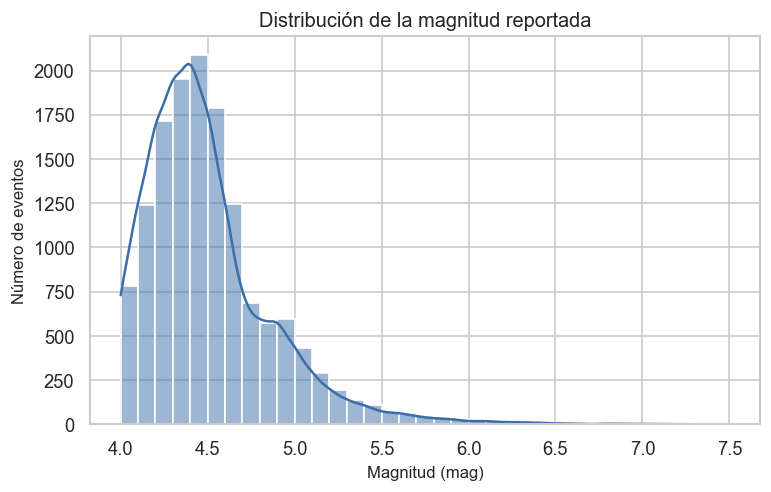

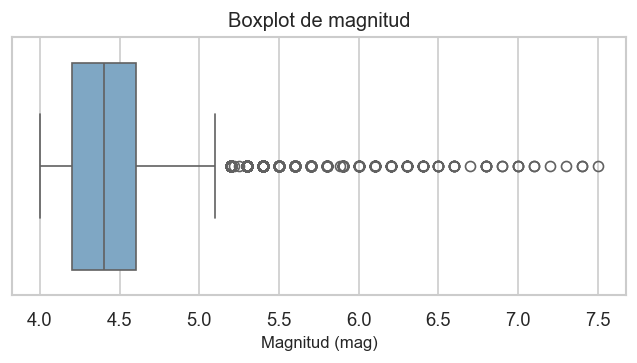

In [13]:
def save_current_figure(name: str):
    for directory in [REPORT_FIG_DIR, OUTPUT_FIG_DIR]:
        plt.savefig(directory / f"{name}.png", bbox_inches="tight")
        plt.savefig(directory / f"{name}.pdf", bbox_inches="tight")
    plt.show()

# 1. Distribución de magnitud
plt.figure(figsize=(7.2, 4.2))
sns.histplot(data=df_model, x="mag", bins=35, kde=True, color="#3b6ea8")
plt.title("Distribución de la magnitud reportada")
plt.xlabel("Magnitud (mag)")
plt.ylabel("Número de eventos")
save_current_figure("fig_hist_mag")

# 2. Boxplot de magnitud
plt.figure(figsize=(6.6, 2.8))
sns.boxplot(data=df_model, x="mag", color="#74a9cf")
plt.title("Boxplot de magnitud")
plt.xlabel("Magnitud (mag)")
save_current_figure("fig_box_mag")

### 3.2. Relaciones principales

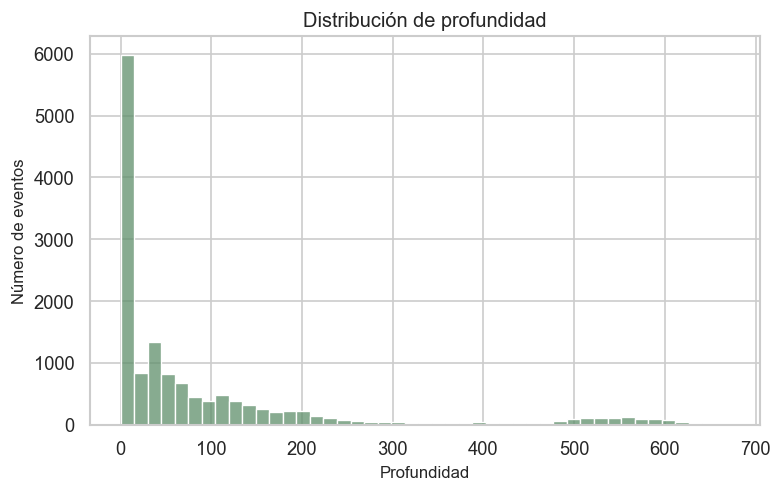

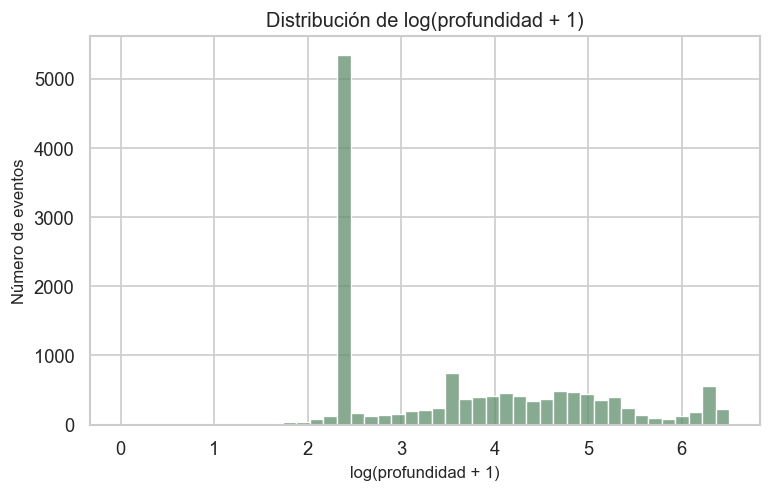

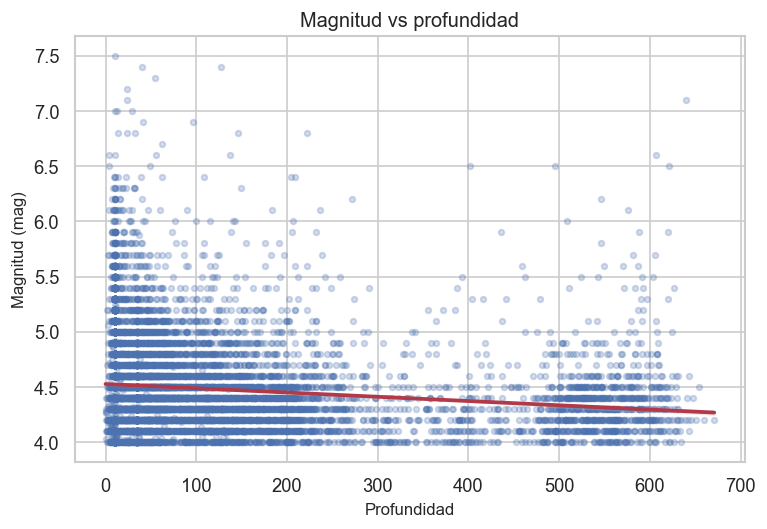

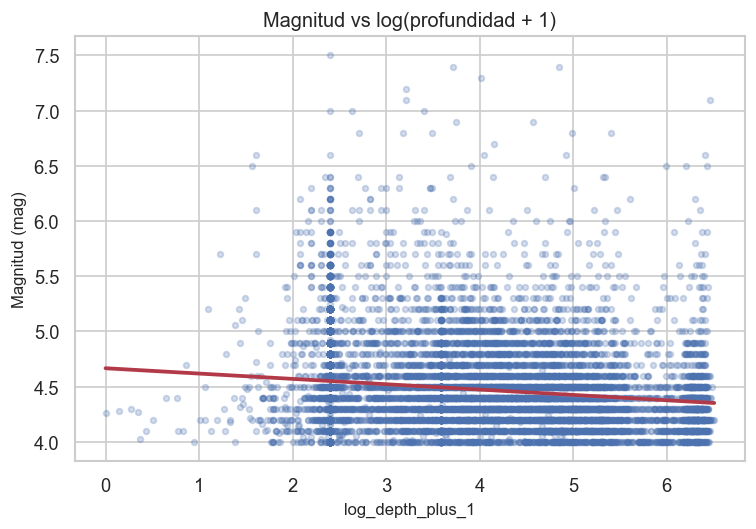

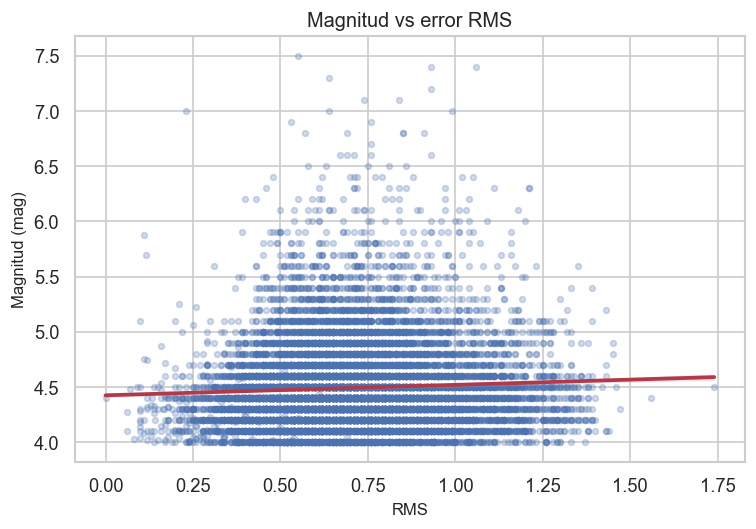

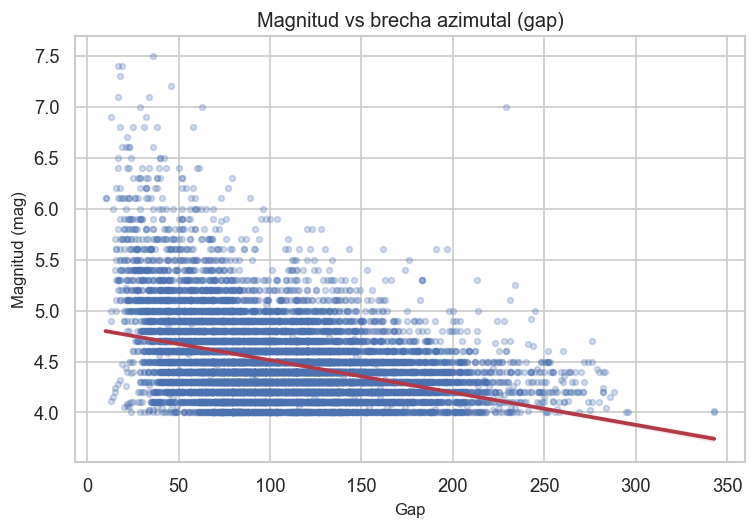

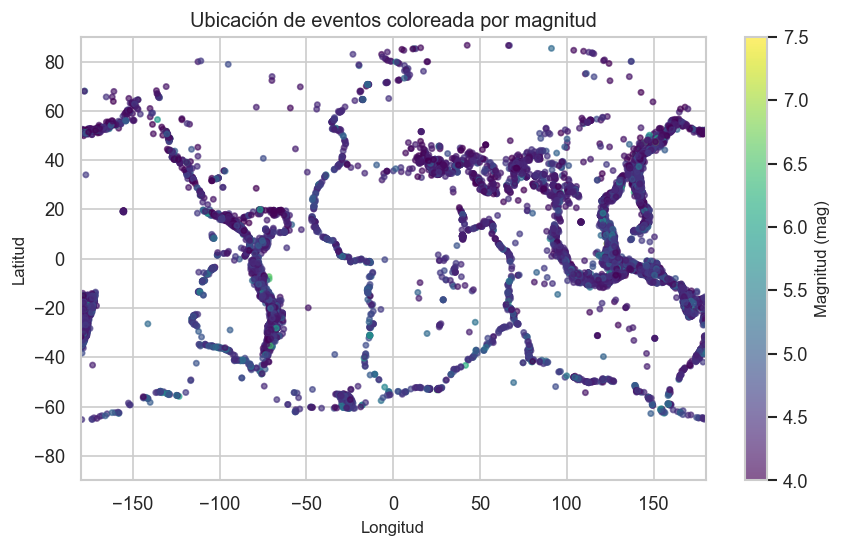

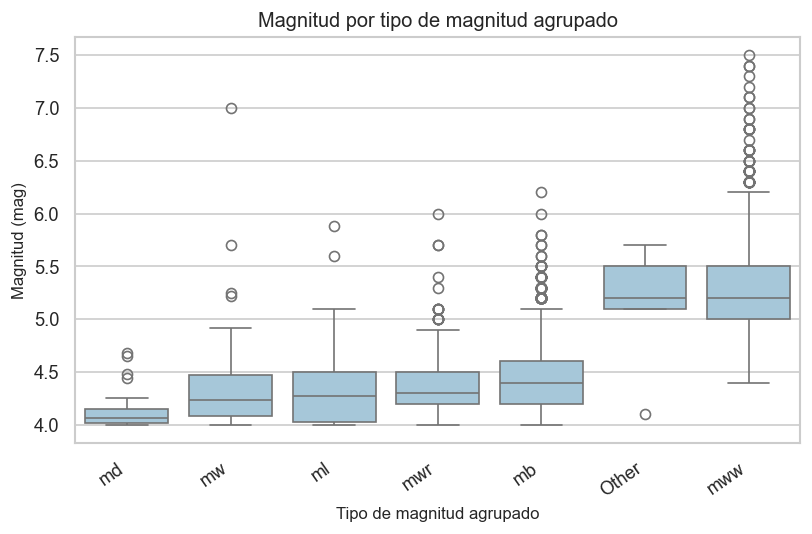

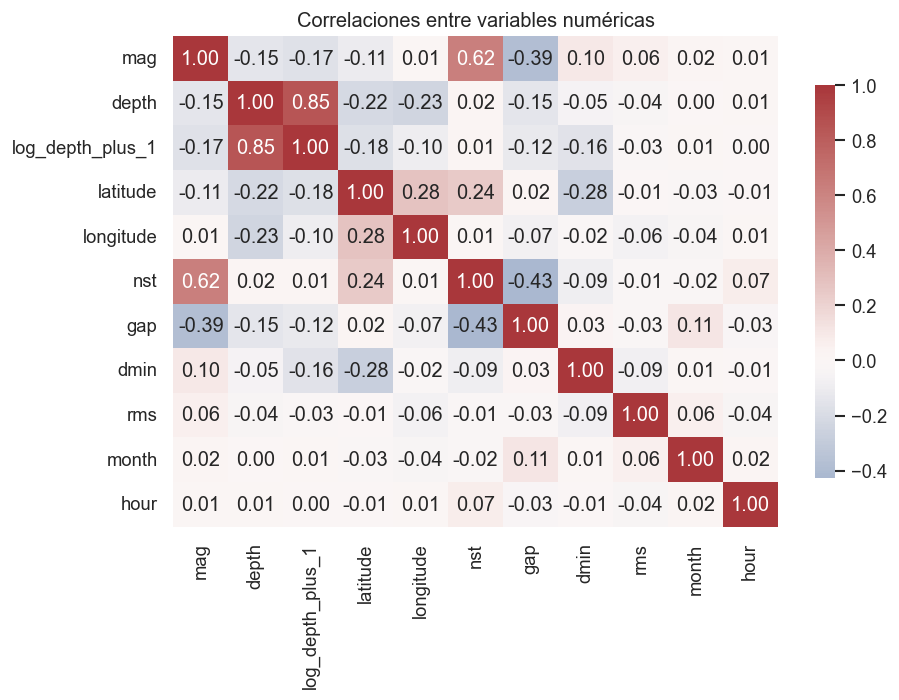

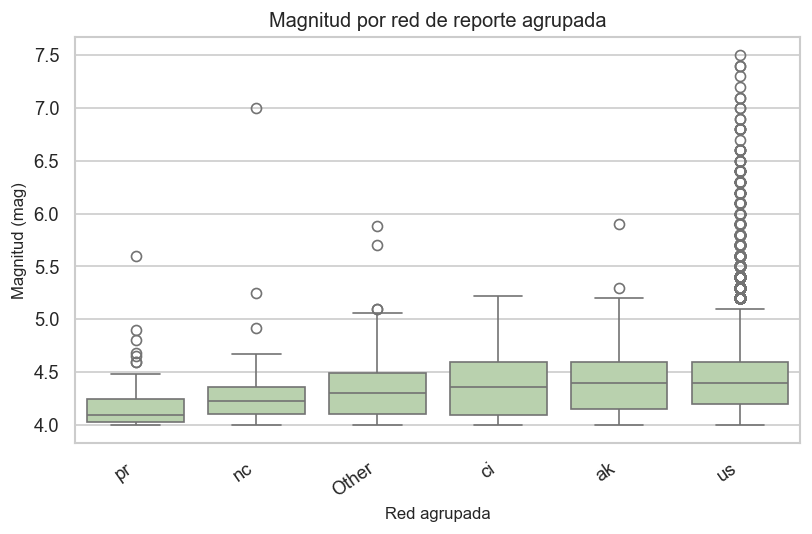

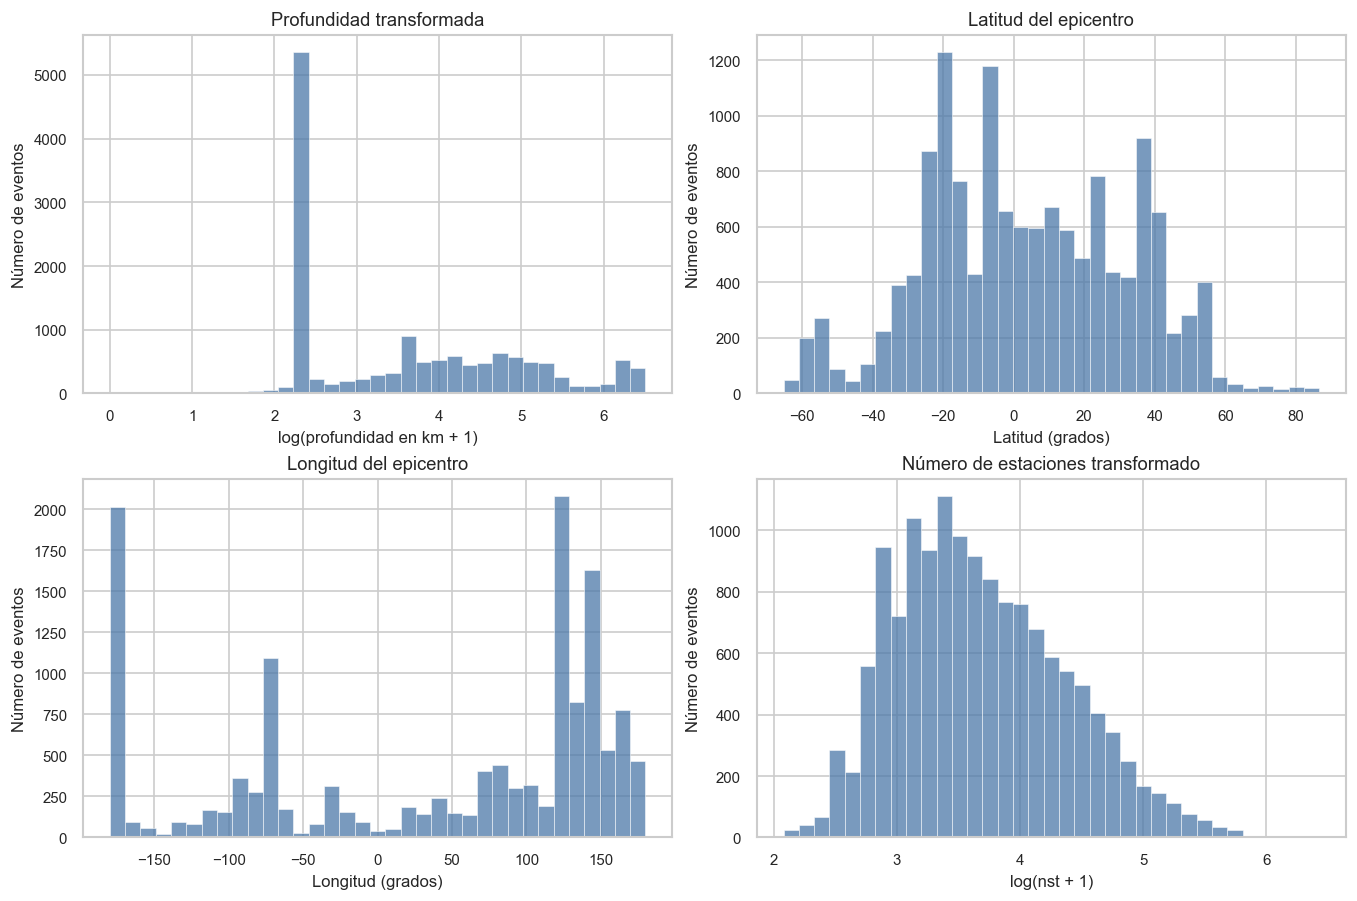

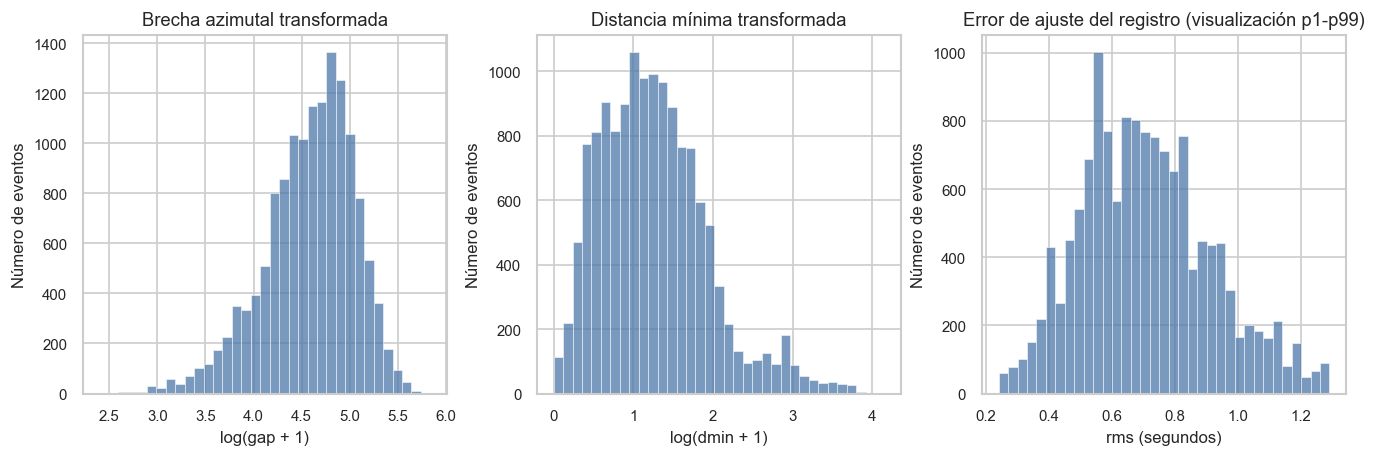

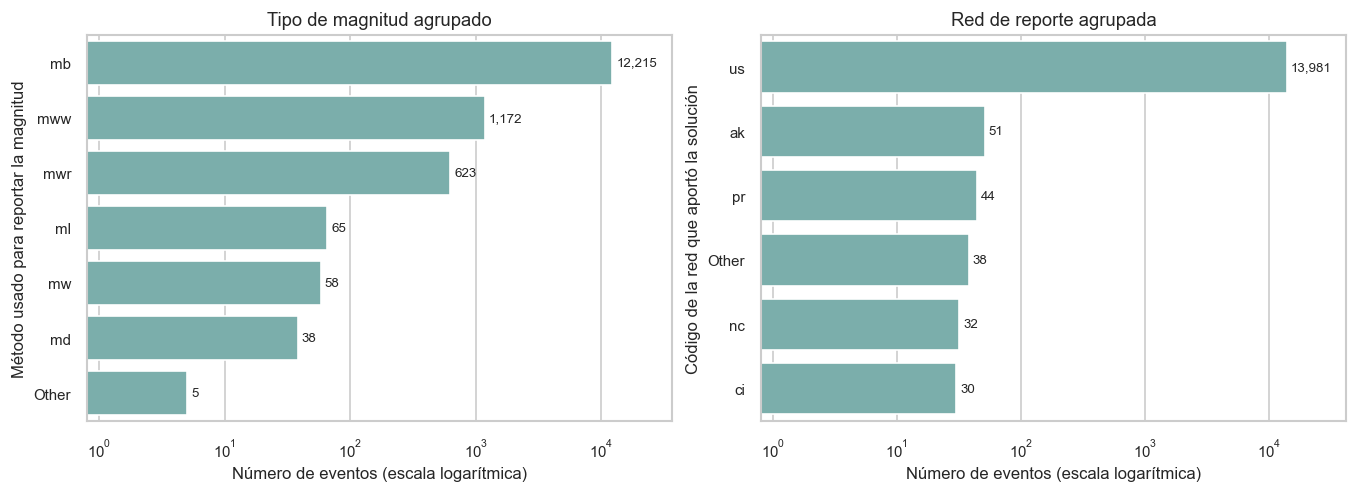

In [14]:
# 3. Distribución de profundidad
if "depth" in df_model.columns:
    plt.figure(figsize=(7.2, 4.2))
    sns.histplot(data=df_model, x="depth", bins=45, kde=False, color="#5f8f6b")
    plt.title("Distribución de profundidad")
    plt.xlabel("Profundidad")
    plt.ylabel("Número de eventos")
    save_current_figure("fig_hist_depth")

#3.1 Distribución de log(profundidad + 1)
if "log_depth_plus_1" in df_model.columns:
    plt.figure(figsize=(7.2, 4.2))
    sns.histplot(data=df_model, x="log_depth_plus_1", bins=45, kde=False, color="#5f8f6b")
    plt.title("Distribución de log(profundidad + 1)")
    plt.xlabel("log(profundidad + 1)")
    plt.ylabel("Número de eventos")
    save_current_figure("fig_hist_log_depth")

# 4. Magnitud vs profundidad
if {"mag", "depth"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "depth"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="depth", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs profundidad")
    plt.xlabel("Profundidad")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_depth")

# 5. Magnitud vs log profundidad
if {"mag", "log_depth_plus_1"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "log_depth_plus_1"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="log_depth_plus_1", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs log(profundidad + 1)")
    plt.xlabel("log_depth_plus_1")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_logdepth")

# 6. Magnitud vs RMS
if {"mag", "rms"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "rms"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="rms", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs error RMS")
    plt.xlabel("RMS")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_rms")

# 7. Magnitud vs gap
if {"mag", "gap"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "gap"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="gap", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs brecha azimutal (gap)")
    plt.xlabel("Gap")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_gap")


# 8. Mapa simple
if {"longitude", "latitude", "mag"}.issubset(df_model.columns):
    plot_df = df_model[["longitude", "latitude", "mag"]].dropna()
    plt.figure(figsize=(8.4, 4.8))
    scatter = plt.scatter(plot_df["longitude"], plot_df["latitude"], c=plot_df["mag"], s=10, alpha=0.65, cmap="viridis")
    plt.colorbar(scatter, label="Magnitud (mag)")
    plt.title("Ubicación de eventos coloreada por magnitud")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    save_current_figure("fig_map_mag")

# 9. Boxplot de magnitud por tipo de magnitud agrupado
if {"mag", "magType_grouped"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "magType_grouped"]].dropna().copy()
    order = plot_df.groupby("magType_grouped", observed=True)["mag"].median().sort_values().index
    plt.figure(figsize=(7.8, 4.4))
    sns.boxplot(data=plot_df, x="magType_grouped", y="mag", order=order, color="#9ecae1")
    plt.title("Magnitud por tipo de magnitud agrupado")
    plt.xlabel("Tipo de magnitud agrupado")
    plt.ylabel("Magnitud (mag)")
    plt.xticks(rotation=35, ha="right")
    save_current_figure("fig_box_mag_magtype")

# 10. Matriz de correlaciones numéricas
corr_vars = ["mag", "depth", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "month", "hour"]
corr_vars = [col for col in corr_vars if col in df_model.columns]
if len(corr_vars) >= 2:
    corr = df_model[corr_vars].corr(numeric_only=True)
    plt.figure(figsize=(8.0, 6.0))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=False, cbar_kws={"shrink": 0.8})
    plt.title("Correlaciones entre variables numéricas")
    plt.tight_layout()
    save_current_figure("fig_corr_numeric")

# 11. Magnitud por red de reporte agrupada
if {"mag", "net_grouped"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "net_grouped"]].dropna().copy()
    order = plot_df.groupby("net_grouped", observed=True)["mag"].median().sort_values().index
    plt.figure(figsize=(7.8, 4.4))
    sns.boxplot(data=plot_df, x="net_grouped", y="mag", order=order, color="#b7d7a8")
    plt.title("Magnitud por red de reporte agrupada")
    plt.xlabel("Red agrupada")
    plt.ylabel("Magnitud (mag)")
    plt.xticks(rotation=35, ha="right")
    save_current_figure("fig_box_mag_net")

# 12. Distribuciones de covariables usadas en los modelos
# Se dividen en tres láminas para que cada panel sea legible en el informe.
df_model["log_nst_plus_1"] = np.log1p(pd.to_numeric(df_model["nst"], errors="coerce").clip(lower=0))
df_model["log_dmin_plus_1"] = np.log1p(pd.to_numeric(df_model["dmin"], errors="coerce").clip(lower=0))
df_model["log_gap_plus_1"] = np.log1p(pd.to_numeric(df_model["gap"], errors="coerce").clip(lower=0))
df_model["log_gap_plus_1"] = np.log1p(pd.to_numeric(df_model["gap"], errors="coerce").clip(lower=0))

def plot_numeric_distributions(specs, name, ncols=2):
    nrows = int(np.ceil(len(specs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(11.2, 3.7 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (var, title, xlabel, trim) in zip(axes, specs):
        values = pd.to_numeric(df_model[var], errors="coerce").dropna()
        subtitle = ""
        if trim and len(values):
            q_low, q_high = values.quantile([0.01, 0.99])
            values = values[(values >= q_low) & (values <= q_high)]
            subtitle = " (visualización p1-p99)"
        sns.histplot(values, bins=35, ax=ax, color="#4C78A8", edgecolor="white", linewidth=0.3)
        ax.set_title(title + subtitle, fontsize=11)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Número de eventos", fontsize=10)
        ax.tick_params(labelsize=9)
    for ax in axes[len(specs):]:
        ax.axis("off")
    save_current_figure(name)

numeric_specs_a = [
    ("log_depth_plus_1", "Profundidad transformada", "log(profundidad en km + 1)", False),
    ("latitude", "Latitud del epicentro", "Latitud (grados)", False),
    ("longitude", "Longitud del epicentro", "Longitud (grados)", False),
    ("log_nst_plus_1", "Número de estaciones transformado", "log(nst + 1)", False),
]
plot_numeric_distributions(numeric_specs_a, "fig_covariates_numeric_a", ncols=2)

numeric_specs_b = [
    ("log_gap_plus_1", "Brecha azimutal transformada", "log(gap + 1)", False),
    ("log_dmin_plus_1", "Distancia mínima transformada", "log(dmin + 1)", False),
    ("rms", "Error de ajuste del registro", "rms (segundos)", True),
]
plot_numeric_distributions(numeric_specs_b, "fig_covariates_numeric_b", ncols=3)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0), constrained_layout=True)
categorical_specs = [
    ("magType_grouped", "Tipo de magnitud agrupado", "Método usado para reportar la magnitud"),
    ("net_grouped", "Red de reporte agrupada", "Código de la red que aportó la solución"),
]
for ax, (var, title, xlabel) in zip(axes, categorical_specs):
    counts = df_model[var].astype("string").fillna("Missing").value_counts().sort_values(ascending=False)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#72B7B2")
    ax.set_xscale("log")
    ax.set_xlim(0.8, counts.max() * 3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Número de eventos (escala logarítmica)", fontsize=10)
    ax.set_ylabel(xlabel, fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    for row, count in enumerate(counts.values):
        ax.text(count * 1.08, row, f"{int(count):,}", va="center", fontsize=8)
save_current_figure("fig_covariates_categorical")


In [15]:
# Cuartiles que complementan la tabla formal de tendencia central y dispersión
quartiles = df_model[["mag", "depth", "nst", "gap", "dmin", "rms"]].quantile([0.25, 0.50, 0.75]).T
quartiles.columns = ["Q1", "Mediana", "Q3"]
display(quartiles.round(3))


,Q1,Mediana,Q3
mag,4.200,4.400,4.600
depth,10.000,34.622,109.492
nst,22.000,35.000,62.000
gap,73.000,102.000,135.000
dmin,1.125,2.284,4.221
rms,0.550,0.690,0.840


### Interpretación del EDA

- La distribución de `mag` permite evaluar la concentración de magnitudes dentro de una muestra truncada en 4. Si la mayor parte de los eventos está cerca del umbral, el modelo debe interpretarse como asociación dentro de eventos moderados o mayores, no como descripción de todos los sismos.
- Los gráficos de `mag` contra `depth` y `log_depth_plus_1` revisan si la transformación logarítmica ofrece una relación más estable para un modelo lineal.
- Los gráficos con `rms` y `gap` conectan la magnitud con características técnicas del registro. Estas variables pueden asociarse con la magnitud reportada, pero no deben leerse como causas físicas directas.
- El mapa longitud-latitud muestra concentración espacial de eventos y anticipa una limitación relevante: la regresión lineal estándar no modela explícitamente dependencia espacial entre observaciones cercanas.
- Los boxplots por `magType_grouped` y `net_grouped` permiten revisar diferencias sistemáticas de nivel medio asociadas a codificaciones del catálogo.
- La matriz de correlaciones orienta el plan de modelos y alerta sobre posible colinealidad entre predictores numéricos.
- La figura compuesta de covariables resume distribuciones según tipo de dato: histogramas para predictores numéricos y barras para categorías agrupadas. Esto justifica transformaciones, agrupación de niveles escasos y controles incluidos en los modelos preliminares.


## 4. Plan de Modelamiento

### 4.1. Modelos lineales candidatos

Los modelos se ajustan con `statsmodels.formula.api` sobre una misma muestra de casos completos para que AIC, BIC y las pruebas F entre modelos anidados sean comparables. Cada paso incorpora un bloque con interpretación sustantiva: profundidad, localización, características técnicas y controles de codificación. Los resultados describen asociaciones dentro del catálogo; no miden capacidad para anticipar eventos futuros.


In [16]:
model_specs = [
    {
        "modelo": "M1",
        "formula": "mag ~ log_depth_plus_1",
        "resumen": "Profundidad transformada",
        "variables": ["mag", "log_depth_plus_1"],
        "propósito": "Evaluar la asociación marginal entre profundidad y magnitud.",
    },
    {
        "modelo": "M2",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude",
        "resumen": "M1 + ubicación",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude"],
        "propósito": "Controlar por localización espacial lineal.",
    },
    {
        "modelo": "M3",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms",
        "resumen": "M2 + técnicas",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms"],
        "propósito": "Agregar cobertura y ajuste técnico del registro.",
    },
    {
        "modelo": "M4",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms + C(magType_grouped)",
        "resumen": "M3 + tipo de magnitud",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "magType_grouped"],
        "propósito": "Estimar diferencias promedio según el método de magnitud reportado.",
    },
    {
        "modelo": "M5",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms + C(magType_grouped) + C(net_grouped)",
        "resumen": "M4 + red",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "magType_grouped", "net_grouped"],
        "propósito": "Evaluar diferencias adicionales asociadas con la red reportante.",
    },
    {
        "modelo": "M6",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + I(latitude**2) + I(longitude**2) + latitude:longitude + nst + gap + dmin + rms + C(magType_grouped)",
        "resumen": "M4 + curvatura espacial",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "magType_grouped"],
        "propósito": "Permitir una asociación espacial no estrictamente lineal.",
    },
]

plan_df = pd.DataFrame([{key: spec[key] for key in ["modelo", "formula", "propósito"]} for spec in model_specs])
display(plan_df)


,modelo,formula,propósito
0,M1,mag ~ log_depth_plus_1,Evaluar la asociación marginal entre profundid...
1,M2,mag ~ log_depth_plus_1 + latitude + longitude,Controlar por localización espacial lineal.
2,M3,mag ~ log_depth_plus_1 + latitude + longitude ...,Agregar cobertura y ajuste técnico del registro.
3,M4,mag ~ log_depth_plus_1 + latitude + longitude ...,Estimar diferencias promedio según el método d...
4,M5,mag ~ log_depth_plus_1 + latitude + longitude ...,Evaluar diferencias adicionales asociadas con ...
5,M6,mag ~ log_depth_plus_1 + latitude + longitude ...,Permitir una asociación espacial no estrictame...


In [17]:
# Se usa la unión de regresores para comparar todos los modelos sobre las mismas observaciones.
common_variables = sorted({var for spec in model_specs for var in spec["variables"]} | {"depth"})
missing_common = [var for var in common_variables if var not in df_model.columns]
if missing_common:
    raise KeyError(f"Faltan variables necesarias para los modelos: {missing_common}")

common_model_data = df_model[common_variables].dropna().copy()
fitted_models = {}
comparison_rows = []

for spec in model_specs:
    fit = smf.ols(spec["formula"], data=common_model_data).fit()
    fitted_models[spec["modelo"]] = fit
    resid = fit.resid
    comparison_rows.append({
        "modelo": spec["modelo"],
        "fórmula resumida": spec["resumen"],
        "n usado": int(fit.nobs),
        "n parámetros": int(fit.df_model + 1),
        "R2": fit.rsquared,
        "R2 ajustado": fit.rsquared_adj,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "RMSE in-sample": float(np.sqrt(np.mean(resid ** 2))),
        "MAE in-sample": float(np.mean(np.abs(resid))),
    })

model_comparison = pd.DataFrame(comparison_rows)
for col in ["R2", "R2 ajustado", "AIC", "BIC", "RMSE in-sample", "MAE in-sample"]:
    model_comparison[col] = pd.to_numeric(model_comparison[col], errors="coerce").round(3)

model_comparison.to_csv(REPORT_TABLE_DIR / "model_comparison.csv", index=False)
model_comparison.to_csv(OUTPUT_TABLE_DIR / "model_comparison.csv", index=False)
latex_comparison = model_comparison[[
    "modelo", "n usado", "n parámetros", "R2 ajustado", "AIC", "BIC", "RMSE in-sample", "MAE in-sample"
]].rename(columns={
    "modelo": "Modelo",
    "n usado": "n",
    "n parámetros": "Parámetros",
    "R2 ajustado": "R2 ajust.",
    "RMSE in-sample": "RMSE",
    "MAE in-sample": "MAE",
})
write_latex_tabular(latex_comparison, REPORT_TABLE_DIR / "model_comparison.tex", column_format="lrrrrrrr")
display(model_comparison)


,modelo,fórmula resumida,n usado,n parámetros,R2,R2 ajustado,AIC,BIC,RMSE in-sample,MAE in-sample
0,M1,Profundidad transformada,14124,2,0.028,0.028,12045.969,12061.080,0.371,0.268
1,M2,M1 + ubicación,14124,4,0.048,0.048,11754.696,11784.919,0.367,0.264
2,M3,M2 + técnicas,14124,8,0.536,0.535,1633.633,1694.078,0.256,0.184
3,M4,M3 + tipo de magnitud,14124,14,0.624,0.624,-1343.832,-1238.053,0.231,0.170
4,M5,M4 + red,14124,18,0.625,0.625,-1375.841,-1239.840,0.230,0.170
5,M6,M4 + curvatura espacial,14124,17,0.633,0.632,-1669.274,-1540.829,0.228,0.168


### Lectura cautelosa de la comparación

La tabla permite estudiar cuánto cambia el ajuste dentro de la muestra al incorporar cada bloque. Como todos los modelos se estiman sobre las mismas observaciones, AIC, BIC y las pruebas F anidadas son comparables. La selección final no se basa solo en el mayor $R^2$: también se consideran parsimonia, interpretación, supuestos, influencia y estabilidad. M4 constituye una referencia interpretable, mientras que M6 evalúa si la curvatura espacial aporta información adicional.


### 4.2. Estrategia de diagnóstico

El modelo M4 se usa como referencia para los diagnósticos porque incluye los tres bloques conceptuales sin añadir todavía términos espaciales de segundo orden. Se combinan gráficos con pruebas formales: Breusch-Pagan para homocedasticidad, Jarque-Bera para normalidad residual, Ramsey RESET para forma funcional, pruebas F/ANOVA para bloques anidados y pruebas t con errores estándar HC3 como análisis de sensibilidad ante heterocedasticidad.


In [18]:
candidate_model_name = "M4"
candidate_model = fitted_models[candidate_model_name]
formula = candidate_model.model.formula
print(f"Modelo candidato para diagnóstico: {candidate_model_name}")
print(formula)


Modelo candidato para diagnóstico: M4
mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms + C(magType_grouped)


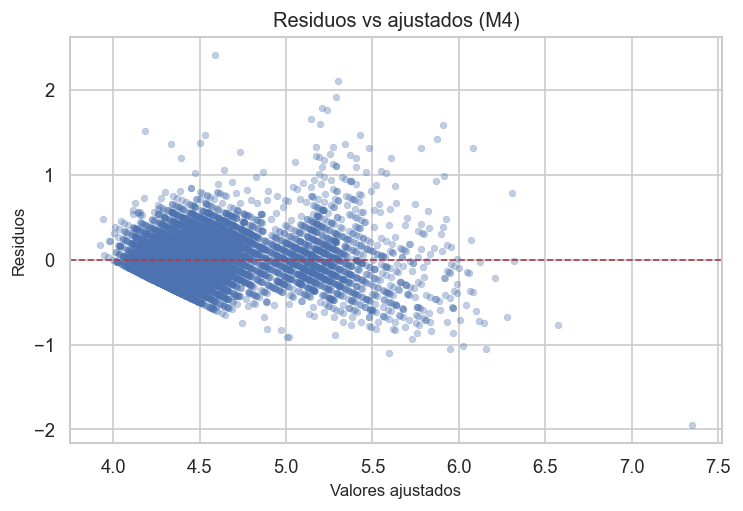

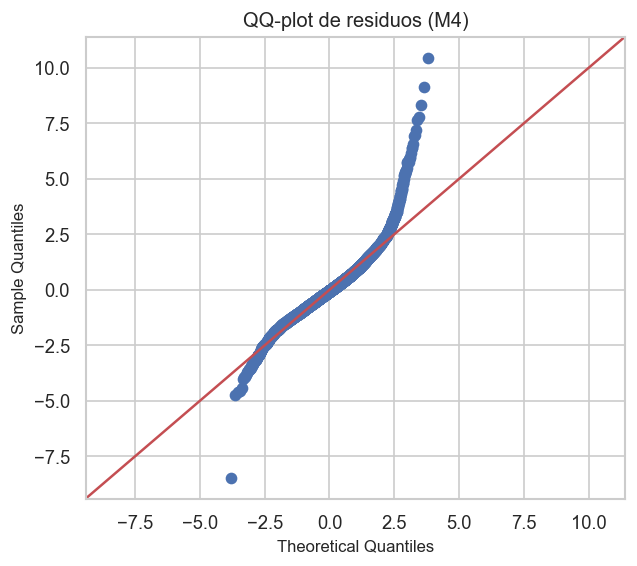

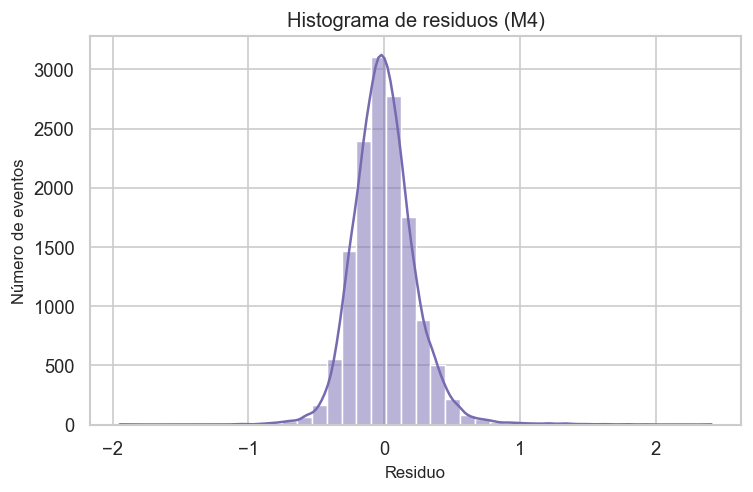

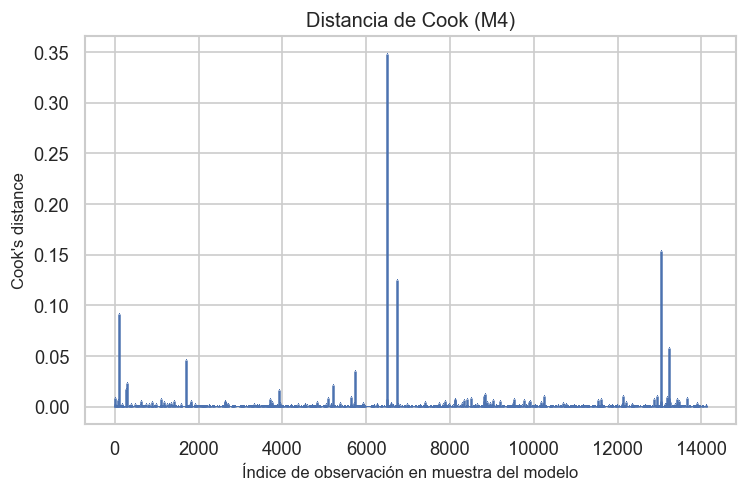

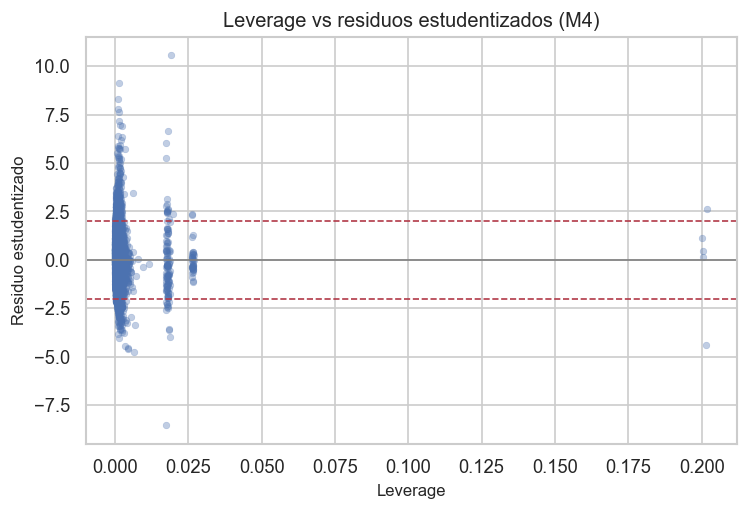

In [19]:
fit = candidate_model
infl = fit.get_influence()
fitted = fit.fittedvalues
resid = fit.resid
studentized = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cooks_d = infl.cooks_distance[0]

plt.figure(figsize=(7.0, 4.4))
sns.scatterplot(x=fitted, y=resid, alpha=0.35, s=16, edgecolor=None)
plt.axhline(0, color="#b23a48", linestyle="--", linewidth=1)
plt.title(f"Residuos vs ajustados ({candidate_model_name})")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
save_current_figure("fig_resid_fitted")

plt.figure(figsize=(5.8, 5.0))
sm.qqplot(resid, line="45", fit=True, ax=plt.gca())
plt.title(f"QQ-plot de residuos ({candidate_model_name})")
save_current_figure("fig_qq_resid")

plt.figure(figsize=(7.0, 4.2))
sns.histplot(resid, bins=40, kde=True, color="#756bb1")
plt.title(f"Histograma de residuos ({candidate_model_name})")
plt.xlabel("Residuo")
plt.ylabel("Número de eventos")
save_current_figure("fig_hist_resid")

plt.figure(figsize=(7.0, 4.2))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
plt.title(f"Distancia de Cook ({candidate_model_name})")
plt.xlabel("Índice de observación en muestra del modelo")
plt.ylabel("Cook's distance")
save_current_figure("fig_cooks_distance")

plt.figure(figsize=(7.0, 4.4))
sns.scatterplot(x=leverage, y=studentized, alpha=0.35, s=16, edgecolor=None)
plt.axhline(0, color="gray", linewidth=1)
plt.axhline(2, color="#b23a48", linestyle="--", linewidth=1)
plt.axhline(-2, color="#b23a48", linestyle="--", linewidth=1)
plt.title(f"Leverage vs residuos estudentizados ({candidate_model_name})")
plt.xlabel("Leverage")
plt.ylabel("Residuo estudentizado")
save_current_figure("fig_leverage_resid")


In [ ]:
def format_pvalue(value):
    return "<0.001" if value < 0.001 else f"{value:.3f}"

residuos = candidate_model.resid
exogenas = candidate_model.model.exog
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuos, exogenas)
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(residuos)
reset_result = linear_reset(candidate_model, power=2, use_f=True)

diagnostic_tests = pd.DataFrame([
    {
        "Prueba": "F global",
        "Estadístico": float(candidate_model.fvalue),
        "p-valor": float(candidate_model.f_pvalue),
        "Conclusión (5%)": "Regresores conjuntamente significativos",
    },
    {
        "Prueba": "Breusch-Pagan",
        "Estadístico": float(bp_lm),
        "p-valor": float(bp_lm_p),
        "Conclusión (5%)": "Varianza residual no constante",
    },
    {
        "Prueba": "Jarque-Bera",
        "Estadístico": float(jb_stat),
        "p-valor": float(jb_p),
        "Conclusión (5%)": "Desviación de normalidad residual",
    },
    {
        "Prueba": "Ramsey RESET",
        "Estadístico": float(np.asarray(reset_result.fvalue).squeeze()),
        "p-valor": float(np.asarray(reset_result.pvalue).squeeze()),
        "Conclusión (5%)": "Forma funcional incompleta",
    },
])
diagnostic_tests["Estadístico"] = diagnostic_tests["Estadístico"].map(lambda value: f"{value:.2f}")
diagnostic_tests["p-valor"] = diagnostic_tests["p-valor"].map(format_pvalue)
diagnostic_tests.to_csv(REPORT_TABLE_DIR / "diagnostic_tests.csv", index=False)
diagnostic_tests.to_csv(OUTPUT_TABLE_DIR / "diagnostic_tests.csv", index=False)
write_latex_tabular(diagnostic_tests, REPORT_TABLE_DIR / "diagnostic_tests.tex", column_format="lrrl")

nested_pairs = [("M1", "M2"), ("M2", "M3"), ("M3", "M4"), ("M4", "M5"), ("M4", "M6")]
nested_rows = []
for reduced, full in nested_pairs:
    test = anova_lm(fitted_models[reduced], fitted_models[full])
    row = test.iloc[1]
    nested_rows.append({
        "Comparación": f"{reduced} vs {full}",
        "gl adicionales": int(row["df_diff"]),
        "F": float(row["F"]),
        "p-valor": float(row["Pr(>F)"]),
    })

nested_tests = pd.DataFrame(nested_rows)
nested_tests["F"] = nested_tests["F"].map(lambda value: f"{value:.2f}")
nested_tests["p-valor"] = nested_tests["p-valor"].map(format_pvalue)
nested_tests.to_csv(REPORT_TABLE_DIR / "nested_model_tests.csv", index=False)
nested_tests.to_csv(OUTPUT_TABLE_DIR / "nested_model_tests.csv", index=False)
write_latex_tabular(nested_tests, REPORT_TABLE_DIR / "nested_model_tests.tex", column_format="lrrr")

raw_depth_formula = candidate_model.model.formula.replace("log_depth_plus_1", "depth")
raw_depth_model = smf.ols(raw_depth_formula, data=common_model_data).fit()
depth_sensitivity = pd.DataFrame([
    {"Especificación": "depth", "R2 ajustado": raw_depth_model.rsquared_adj, "AIC": raw_depth_model.aic, "BIC": raw_depth_model.bic},
    {"Especificación": "log(depth + 1)", "R2 ajustado": candidate_model.rsquared_adj, "AIC": candidate_model.aic, "BIC": candidate_model.bic},
]).round(3)
depth_sensitivity.to_csv(REPORT_TABLE_DIR / "depth_transformation_sensitivity.csv", index=False)
depth_sensitivity.to_csv(OUTPUT_TABLE_DIR / "depth_transformation_sensitivity.csv", index=False)
write_latex_tabular(depth_sensitivity, REPORT_TABLE_DIR / "depth_transformation_sensitivity.tex", column_format="lrrr")

robust_fit = candidate_model.get_robustcov_results(cov_type="HC3")
robust_ci = robust_fit.conf_int()
robust_coefficients = pd.DataFrame({
    "término": candidate_model.model.exog_names,
    "estimación": robust_fit.params,
    "EE HC3": robust_fit.bse,
    "t": robust_fit.tvalues,
    "p-valor": robust_fit.pvalues,
    "IC 95% inferior": robust_ci[:, 0],
    "IC 95% superior": robust_ci[:, 1],
}).round(4)
robust_coefficients.to_csv(REPORT_TABLE_DIR / "robust_coefficients_m4.csv", index=False)
robust_coefficients.to_csv(OUTPUT_TABLE_DIR / "robust_coefficients_m4.csv", index=False)

display(diagnostic_tests)
display(nested_tests)
display(depth_sensitivity)


,Prueba,Estadístico,p-valor,Conclusión (5%)
0,F global,1802.16,<0.001,Regresores conjuntamente significativos
1,Breusch-Pagan,1656.34,<0.001,Varianza residual no constante
2,Jarque-Bera,18919.05,<0.001,Desviación de normalidad residual
3,Ramsey RESET,291.05,<0.001,Forma funcional incompleta


,Comparación,gl adicionales,F,p-valor
0,M1 vs M2,2,149.15,<0.001
1,M2 vs M3,4,3700.48,<0.001
2,M3 vs M4,6,554.35,<0.001
3,M4 vs M5,4,10.00,<0.001
4,M4 vs M6,3,111.65,<0.001


,Especificación,R2 ajustado,AIC,BIC
0,depth,0.621,-1231.500,-1125.722
1,log(depth + 1),0.624,-1343.832,-1238.053


**Interpretación de las pruebas:** los contrastes se leen junto con los gráficos y el tamaño muestral. Un p-valor pequeño en Breusch-Pagan motiva reportar errores estándar robustos HC3; Jarque-Bera es muy sensible con más de 14 mil observaciones, por lo que la relevancia práctica de la no normalidad se evalúa también con el QQ-plot. RESET examina si M4 deja estructura funcional sistemática, mientras que las pruebas F parciales cuantifican el aporte conjunto de cada bloque sin interpretar sus coeficientes como causas.


In [21]:
vif_vars = ["log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms"]
vif_vars = [col for col in vif_vars if col in df_model.columns]
vif_data = df_model[vif_vars].dropna().copy()
if {"latitude", "longitude"}.issubset(vif_data.columns) and candidate_model_name == "M6":
    vif_data["latitude_sq"] = vif_data["latitude"] ** 2
    vif_data["longitude_sq"] = vif_data["longitude"] ** 2
    vif_data["lat_lon"] = vif_data["latitude"] * vif_data["longitude"]

if len(vif_vars) >= 2 and len(vif_data) > 0:
    X = sm.add_constant(vif_data, has_constant="add")
    vif_rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        try:
            vif_value = variance_inflation_factor(X.values, i)
        except Exception:
            vif_value = np.nan
        vif_rows.append({"variable": col, "VIF": vif_value})
    vif_table = pd.DataFrame(vif_rows)
    vif_table["VIF"] = vif_table["VIF"].round(3)
else:
    vif_table = pd.DataFrame(columns=["variable", "VIF"])

vif_table.to_csv(REPORT_TABLE_DIR / "vif_table.csv", index=False)
vif_table.to_csv(OUTPUT_TABLE_DIR / "vif_table.csv", index=False)
write_latex_tabular(vif_table, REPORT_TABLE_DIR / "vif_table.tex", column_format="lr")
display(vif_table)


,variable,VIF
0,log_depth_plus_1,1.110
1,latitude,1.360
2,longitude,1.128
3,nst,1.347
4,gap,1.287
5,dmin,1.157
6,rms,1.018


### Interpretación preliminar de diagnósticos

Los residuos contra ajustados y RESET permiten evaluar si la media condicional está adecuadamente representada. El QQ-plot, el histograma y Jarque-Bera describen la forma de los residuos; la normalidad no es necesaria para estimar por MCO, pero sí afecta la inferencia exacta en muestras pequeñas. Breusch-Pagan evalúa constancia de varianza y, si se rechaza, la tabla de coeficientes HC3 permite revisar la estabilidad de pruebas t e intervalos. Cook y leverage identifican observaciones potencialmente influyentes, mientras que VIF resume colinealidad. La posible dependencia espacial residual se mantiene como limitación: un CAR no es directo para eventos puntuales sin agregación territorial.


## 5. Desarrollo, selección y validación del modelo final

M4 se conserva como línea base, pero ninguna transformación se adopta solo porque aumente $R^2$. Cada cambio se evalúa sobre la misma muestra y debe cumplir cuatro condiciones: responder a una dificultad concreta de especificación, conservar una interpretación defendible, no producir colinealidad o influencia inaceptables y mejorar la estabilidad fuera de muestra.

La respuesta `mag` permanece en su escala publicada. La magnitud sísmica ya tiene interpretación logarítmica; aplicar otro logaritmo produciría el logaritmo de una escala logarítmica. Box-Cox se examina formalmente como diagnóstico, incluyendo su jacobiano, pero no se adopta sin revisar positividad, truncamiento, supuestos residuales y retransfomación.

In [22]:
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.stattools import acf

analysis_columns = [
    "mag", "depth", "log_depth_plus_1", "latitude", "longitude", "nst", "gap",
    "dmin", "rms", "magType_grouped", "net_grouped", "region_grouped", "time", "id"
]
final_raw = df_model[analysis_columns].dropna(
    subset=["mag", "depth", "latitude", "longitude", "nst", "gap", "dmin", "rms", "magType_grouped"]
).copy()
final_raw["log_depth_clipped"] = np.log1p(final_raw["depth"].clip(lower=0))
if (final_raw["depth"] <= -1).any():
    raise ValueError("log1p(depth) sin recorte requiere depth > -1 en toda la muestra.")
final_raw["log_depth_unclipped"] = np.log1p(final_raw["depth"])
final_raw["log_nst_plus_1"] = np.log1p(final_raw["nst"].clip(lower=0))
final_raw["log_gap_plus_1"] = np.log1p(final_raw["gap"].clip(lower=0))
final_raw["log_dmin_plus_1"] = np.log1p(final_raw["dmin"].clip(lower=0))
final_raw["log_rms_plus_1"] = np.log1p(final_raw["rms"].clip(lower=0))

mag_levels = list(pd.Series(final_raw["magType_grouped"].astype(str)).value_counts().index)
mag_levels = ["mb"] + [level for level in mag_levels if level != "mb"]
final_raw["magType_grouped"] = pd.Categorical(final_raw["magType_grouped"].astype(str), categories=mag_levels)

scale_map = {
    "depth": "z_depth",
    "latitude": "z_latitude",
    "longitude": "z_longitude",
    "nst": "z_nst",
    "gap": "z_gap",
    "dmin": "z_dmin",
    "log_nst_plus_1": "z_log_nst",
    "log_gap_plus_1": "z_log_gap",
    "log_dmin_plus_1": "z_log_dmin",
    "rms": "z_rms",
    "log_rms_plus_1": "z_log_rms",
    "log_depth_clipped": "z_log_depth_clipped",
    "log_depth_unclipped": "z_log_depth_unclipped",
}

def standardize_from_reference(reference, target):
    result = target.copy()
    scaling = {}
    for raw_name, z_name in scale_map.items():
        center = float(reference[raw_name].mean())
        spread = float(reference[raw_name].std(ddof=0))
        if not np.isfinite(spread) or spread == 0:
            spread = 1.0
        result[z_name] = (result[raw_name] - center) / spread
        scaling[raw_name] = {"media": center, "desviación": spread}
    result["magType_grouped"] = pd.Categorical(
        result["magType_grouped"].astype(str), categories=mag_levels
    )
    return result, scaling

final_model_data, final_scaling = standardize_from_reference(final_raw, final_raw)
pd.DataFrame(final_scaling).T.to_csv(REPORT_TABLE_DIR / "final_scaling.csv")

mag_factor = "C(magType_grouped, Treatment(reference='mb'))"
g0_formula = (
    "mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms + " + mag_factor
)
g1_formula = (
    "mag ~ z_depth + z_latitude + z_longitude + z_log_nst + z_log_gap + "
    "z_log_dmin + z_rms + " + mag_factor
)
g2_formula = g1_formula + (
    " + I(z_depth**2) + I(z_latitude**2) + I(z_longitude**2) + z_latitude:z_longitude"
    " + I(z_log_nst**2) + I(z_log_gap**2) + I(z_log_dmin**2) + I(z_rms**2)"
)
g3_formula = g2_formula + (
    " + z_log_nst:z_log_gap + z_log_nst:z_log_dmin + z_log_gap:z_log_dmin"
    " + z_depth:z_latitude + z_depth:z_longitude"
)
gfinal_formula = g1_formula + (
    " + I(z_depth**2) + I(z_latitude**2) + I(z_longitude**2) + z_latitude:z_longitude"
    " + I(z_log_gap**2) + I(z_log_dmin**2)"
    " + z_log_nst:z_log_gap + z_log_nst:z_log_dmin"
    " + z_depth:z_longitude"
)

final_specs = {
    "M4 base": g0_formula,
    "G1 escalas": g1_formula,
    "G2 curvatura": g2_formula,
    "G3 completo": g3_formula,
    "G final": gfinal_formula,
}
final_fits = {name: smf.ols(formula, data=final_model_data).fit() for name, formula in final_specs.items()}
final_fit = final_fits["G final"]

selection_rows = []
for name, fit_model in final_fits.items():
    selection_rows.append({
        "Modelo": name,
        "n": int(fit_model.nobs),
        "Parámetros": int(fit_model.df_model + 1),
        "R2 ajustado": fit_model.rsquared_adj,
        "AIC": fit_model.aic,
        "BIC": fit_model.bic,
        "RMSE": np.sqrt(np.mean(fit_model.resid**2)),
        "MAE": np.mean(np.abs(fit_model.resid)),
    })
final_model_comparison = pd.DataFrame(selection_rows).round(4)
final_model_comparison.to_csv(REPORT_TABLE_DIR / "final_model_comparison.csv", index=False)
final_model_comparison.to_csv(OUTPUT_TABLE_DIR / "final_model_comparison.csv", index=False)
write_latex_tabular(final_model_comparison, REPORT_TABLE_DIR / "final_model_comparison.tex", column_format="lrrrrrrr")
display(final_model_comparison)

,Modelo,n,Parámetros,R2 ajustado,AIC,BIC,RMSE,MAE
0,M4 base,14124,14,0.6238,-1343.8322,-1238.0534,0.2305,0.1705
1,G1 escalas,14124,14,0.6454,-2182.0504,-2076.2715,0.2238,0.1656
2,G2 curvatura,14124,22,0.6676,-3086.8730,-2920.6491,0.2166,0.1593
3,G3 completo,14124,27,0.6714,-3244.3557,-3040.3536,0.2153,0.1580
4,G final,14124,23,0.6715,-3248.8641,-3075.0846,0.2153,0.1580


### 5.1. Elección de escala para profundidad

La asimetría de `depth` no basta para justificar un logaritmo, porque MCO no exige normalidad de los predictores. La decisión se basa en la forma de la media condicional. Se comparan modelos con la misma respuesta y observaciones: profundidad lineal, profundidad cuadrática, log profundidad lineal y log profundidad cuadrática. Los modelos lineal y cuadrático dentro de cada escala son anidados; entre escalas son no anidados, por lo que se usan AIC, BIC, error y validación, no una prueba F entre `depth` y `log(depth+1)`.

In [23]:
def depth_formula(depth_term, include_square):
    formula = (
        f"mag ~ {depth_term} + z_latitude + z_longitude + z_log_nst + z_log_gap + z_log_dmin + z_rms + "
        + mag_factor
        + " + I(z_latitude**2) + I(z_longitude**2) + z_latitude:z_longitude"
        + " + I(z_log_gap**2) + I(z_log_dmin**2)"
        + " + z_log_nst:z_log_gap + z_log_nst:z_log_dmin"
        + f" + {depth_term}:z_longitude"
    )
    if include_square:
        formula += f" + I({depth_term}**2)"
    return formula

depth_specs = {
    "depth lineal": depth_formula("z_depth", False),
    "depth + depth²": depth_formula("z_depth", True),
    "log1p(depth.clip(0)) lineal": depth_formula("z_log_depth_clipped", False),
    "log1p(depth.clip(0)) + cuadrado": depth_formula("z_log_depth_clipped", True),
    "log1p(depth) + cuadrado": depth_formula("z_log_depth_unclipped", True),
}
depth_fits = {name: smf.ols(formula, data=final_model_data).fit() for name, formula in depth_specs.items()}

def prepare_train_test(train_raw, test_raw):
    train_ready, scaling = standardize_from_reference(train_raw, train_raw)
    test_ready = test_raw.copy()
    for raw_name, z_name in scale_map.items():
        center = scaling[raw_name]["media"]
        spread = scaling[raw_name]["desviación"]
        test_ready[z_name] = (test_ready[raw_name] - center) / spread
    train_ready["magType_grouped"] = pd.Categorical(train_ready["magType_grouped"].astype(str), categories=mag_levels)
    test_ready["magType_grouped"] = pd.Categorical(test_ready["magType_grouped"].astype(str), categories=mag_levels)
    return train_ready, test_ready

depth_cv_rows = []
for fold, (train_idx, test_idx) in enumerate(KFold(n_splits=5, shuffle=True, random_state=2307).split(final_raw), start=1):
    train_ready, test_ready = prepare_train_test(final_raw.iloc[train_idx], final_raw.iloc[test_idx])
    for name, formula in depth_specs.items():
        fit_fold = smf.ols(formula, data=train_ready).fit()
        pred = fit_fold.predict(test_ready)
        depth_cv_rows.append({
            "Especificación": name, "Pliegue": fold,
            "CV RMSE": np.sqrt(mean_squared_error(test_ready["mag"], pred)),
            "CV MAE": mean_absolute_error(test_ready["mag"], pred),
            "CV R2": r2_score(test_ready["mag"], pred),
        })
depth_cv = pd.DataFrame(depth_cv_rows).groupby("Especificación", as_index=False).mean(numeric_only=True)

depth_rows = []
for name, fit_model in depth_fits.items():
    cv_row = depth_cv.loc[depth_cv["Especificación"] == name].iloc[0]
    depth_rows.append({
        "Especificación": name,
        "Parámetros": int(fit_model.df_model + 1),
        "R2 ajustado": fit_model.rsquared_adj,
        "AIC": fit_model.aic,
        "BIC": fit_model.bic,
        "RMSE": np.sqrt(np.mean(fit_model.resid**2)),
        "CV RMSE": cv_row["CV RMSE"],
    })
depth_comparison = pd.DataFrame(depth_rows).round(4)
depth_comparison.to_csv(REPORT_TABLE_DIR / "depth_final_comparison.csv", index=False)
write_latex_tabular(depth_comparison, REPORT_TABLE_DIR / "depth_final_comparison.tex", column_format="lrrrrrr")

depth_tests = []
for reduced, full, label in [
    ("depth lineal", "depth + depth²", "Cuadrático en depth"),
    ("log1p(depth.clip(0)) lineal", "log1p(depth.clip(0)) + cuadrado", "Cuadrático en log depth"),
]:
    result = anova_lm(depth_fits[reduced], depth_fits[full]).iloc[1]
    depth_tests.append({"Contraste anidado": label, "F": result["F"], "p-valor": result["Pr(>F)"]})
depth_tests = pd.DataFrame(depth_tests)
depth_tests.to_csv(REPORT_TABLE_DIR / "depth_quadratic_tests.csv", index=False)

negative_depth_sensitivity = final_raw.loc[
    final_raw["depth"] < 0, ["id", "depth", "log_depth_clipped", "log_depth_unclipped"]
]
negative_depth_sensitivity.to_csv(REPORT_TABLE_DIR / "negative_depth_sensitivity.csv", index=False)

display(depth_comparison)
display(depth_tests)
display(negative_depth_sensitivity)

,Especificación,Parámetros,R2 ajustado,AIC,BIC,RMSE,CV RMSE
0,depth lineal,22,0.6662,-3026.3405,-2860.1166,0.2170,0.2178
1,depth + depth²,23,0.6715,-3248.8641,-3075.0846,0.2153,0.2161
2,log1p(depth.clip(0)) lineal,22,0.6648,-2966.1437,-2799.9198,0.2175,0.2184
3,log1p(depth.clip(0)) + cuadrado,23,0.6710,-3230.0318,-3056.2523,0.2155,0.2162
4,log1p(depth) + cuadrado,23,0.6710,-3230.0010,-3056.2215,0.2155,0.2162


,Contraste anidado,F,p-valor
0,Cuadrático en depth,225.949081,1.125129e-50
1,Cuadrático en log depth,267.969441,1.115677e-59


,id,depth,log_depth_clipped,log_depth_unclipped
13178,nc75099566,-0.07,0.0,-0.072571


La profundidad cuadrática en escala original se adopta porque mejora ajuste y validación frente al log lineal y al log cuadrático. El cuadrado no significa que la profundidad “cause” magnitud: permite que la pendiente local cambie con la profundidad. Como `depth` y `depth²` están correlacionadas por construcción, sus coeficientes se interpretan conjuntamente y se revisan VIF, número de condición y significancia del bloque.

La versión recortada y `log1p(depth)` sin recorte producen resultados prácticamente idénticos: solo un evento tiene profundidad -0.07 km y cumple `depth > -1`. Por tanto, el tratamiento de esa observación no determina la selección. El log se conserva en el EDA y como sensibilidad, pero deja de ser el predictor principal.

### 5.2. Transformaciones de las demás covariables

`nst`, `gap`, `dmin` y `rms` se evalúan por separado en escala original y `log1p`. La condición de dominio se cumple porque son no negativas; `log1p` además admite ceros. La motivación es representar cambios marginales decrecientes, no hacer normales los predictores. Se mantiene una transformación solo si mejora criterios de información y validación con el mismo número de parámetros.

In [24]:
def predictor_formula(nst_term, gap_term, dmin_term, rms_term):
    return (
        f"mag ~ z_depth + z_latitude + z_longitude + {nst_term} + {gap_term} + {dmin_term} + {rms_term} + "
        + mag_factor
        + " + I(z_depth**2) + I(z_latitude**2) + I(z_longitude**2) + z_latitude:z_longitude"
        + f" + I({gap_term}**2) + I({dmin_term}**2)"
        + f" + {nst_term}:{gap_term} + {nst_term}:{dmin_term} + z_depth:z_longitude"
    )

predictor_specs = {
    "Final: log nst, log gap, log dmin, rms": predictor_formula("z_log_nst", "z_log_gap", "z_log_dmin", "z_rms"),
    "nst original": predictor_formula("z_nst", "z_log_gap", "z_log_dmin", "z_rms"),
    "gap original": predictor_formula("z_log_nst", "z_gap", "z_log_dmin", "z_rms"),
    "dmin original": predictor_formula("z_log_nst", "z_log_gap", "z_dmin", "z_rms"),
    "log rms": predictor_formula("z_log_nst", "z_log_gap", "z_log_dmin", "z_log_rms"),
}
predictor_fits = {name: smf.ols(formula, data=final_model_data).fit() for name, formula in predictor_specs.items()}

predictor_cv_rows = []
for fold, (train_idx, test_idx) in enumerate(KFold(n_splits=5, shuffle=True, random_state=2307).split(final_raw), start=1):
    train_ready, test_ready = prepare_train_test(final_raw.iloc[train_idx], final_raw.iloc[test_idx])
    for name, formula in predictor_specs.items():
        fit_fold = smf.ols(formula, data=train_ready).fit()
        pred = fit_fold.predict(test_ready)
        predictor_cv_rows.append({
            "Especificación": name,
            "Pliegue": fold,
            "CV RMSE": np.sqrt(mean_squared_error(test_ready["mag"], pred)),
        })
predictor_cv = pd.DataFrame(predictor_cv_rows).groupby("Especificación", as_index=False)["CV RMSE"].mean()

predictor_rows = []
for name, fit_model in predictor_fits.items():
    predictor_rows.append({
        "Especificación": name,
        "R2 ajustado": fit_model.rsquared_adj,
        "AIC": fit_model.aic,
        "BIC": fit_model.bic,
        "RMSE": np.sqrt(np.mean(fit_model.resid**2)),
        "CV RMSE": predictor_cv.loc[predictor_cv["Especificación"] == name, "CV RMSE"].iloc[0],
    })
predictor_transform_comparison = pd.DataFrame(predictor_rows).round(4)
predictor_transform_comparison.to_csv(REPORT_TABLE_DIR / "predictor_transform_comparison.csv", index=False)
write_latex_tabular(
    predictor_transform_comparison,
    REPORT_TABLE_DIR / "predictor_transform_comparison.tex",
    column_format="lrrrrr",
)
display(predictor_transform_comparison)

,Especificación,R2 ajustado,AIC,BIC,RMSE,CV RMSE
0,"Final: log nst, log gap, log dmin, rms",0.6715,-3248.8641,-3075.0846,0.2153,0.2161
1,nst original,0.6447,-2144.6305,-1970.8510,0.2239,0.2249
2,gap original,0.6706,-3213.6513,-3039.8718,0.2156,0.2164
3,dmin original,0.6712,-3237.6676,-3063.8881,0.2154,0.2162
4,log rms,0.6715,-3249.6315,-3075.8520,0.2153,0.2161


Los resultados respaldan `log1p(nst)` de manera clara y `log1p(dmin)` de manera moderada. `log1p(gap)` produce una mejora pequeña pero consistente en AIC, BIC y CV-RMSE; además representa que una misma diferencia en grados puede tener menor efecto marginal cuando la brecha ya es grande. `log1p(rms)` cambia el ajuste de forma despreciable, por lo que `rms` se conserva en segundos. La estandarización posterior no cambia valores ajustados ni $R^2$: centra el intercepto, iguala unidades y reduce colinealidad no esencial en cuadrados e interacciones.

In [25]:
def classical_partial_row(reduced_name, full_name, label, robust_terms):
    classical = anova_lm(final_fits[reduced_name], final_fits[full_name]).iloc[1]
    full_fit = final_fits[full_name]
    robust = full_fit.get_robustcov_results(cov_type="HC3")
    names = full_fit.model.exog_names
    present = [term for term in robust_terms if term in names]
    restriction = np.zeros((len(present), len(names)))
    for row, term in enumerate(present):
        restriction[row, names.index(term)] = 1
    robust_test = robust.wald_test(restriction, use_f=True, scalar=True)
    return {
        "Comparación": label,
        "gl": int(classical["df_diff"]),
        "F clásico": float(classical["F"]),
        "p clásico": float(classical["Pr(>F)"]),
        "F HC3": float(robust_test.statistic),
        "p HC3": float(robust_test.pvalue),
    }

g2_added = [
    "I(z_depth ** 2)", "I(z_latitude ** 2)", "I(z_longitude ** 2)", "z_latitude:z_longitude",
    "I(z_log_nst ** 2)", "I(z_log_gap ** 2)", "I(z_log_dmin ** 2)", "I(z_rms ** 2)",
]
g3_added = [
    "z_log_nst:z_log_gap", "z_log_nst:z_log_dmin", "z_log_gap:z_log_dmin",
    "z_depth:z_latitude", "z_depth:z_longitude",
]
removed_terms = [
    "I(z_log_nst ** 2)", "I(z_rms ** 2)", "z_log_gap:z_log_dmin", "z_depth:z_latitude",
]

selection_tests = pd.DataFrame([
    classical_partial_row("G1 escalas", "G2 curvatura", "G1 vs G2: curvatura", g2_added),
    classical_partial_row("G2 curvatura", "G3 completo", "G2 vs G3: interacciones", g3_added),
    classical_partial_row("G final", "G3 completo", "G final vs G3: términos retirados", removed_terms),
])
for col in ["F clásico", "F HC3"]:
    selection_tests[col] = selection_tests[col].round(3)
for col in ["p clásico", "p HC3"]:
    selection_tests[col] = selection_tests[col].map(format_pvalue)
selection_tests.to_csv(REPORT_TABLE_DIR / "final_selection_tests.csv", index=False)
write_latex_tabular(selection_tests, REPORT_TABLE_DIR / "final_selection_tests.tex", column_format="lrrrrr")

y_final = np.asarray(final_fit.model.endog)
sst = float(np.sum((y_final - np.mean(y_final))**2))
sse = float(np.sum(final_fit.resid**2))
ssr = sst - sse
global_anova = pd.DataFrame([
    {"Fuente": "Regresión", "SC": ssr, "gl": int(final_fit.df_model), "CM": ssr/final_fit.df_model, "F": final_fit.fvalue, "p-valor": final_fit.f_pvalue},
    {"Fuente": "Error", "SC": sse, "gl": int(final_fit.df_resid), "CM": sse/final_fit.df_resid, "F": np.nan, "p-valor": np.nan},
    {"Fuente": "Total", "SC": sst, "gl": int(final_fit.nobs-1), "CM": np.nan, "F": np.nan, "p-valor": np.nan},
])
global_anova_display = global_anova.copy()
for col in ["SC", "CM", "F"]:
    global_anova_display[col] = global_anova_display[col].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
global_anova_display["p-valor"] = global_anova_display["p-valor"].map(lambda x: "" if pd.isna(x) else format_pvalue(x))
global_anova_display.to_csv(REPORT_TABLE_DIR / "final_anova.csv", index=False)
write_latex_tabular(global_anova_display, REPORT_TABLE_DIR / "final_anova.tex", column_format="lrrrrr")

robust_final = final_fit.get_robustcov_results(cov_type="HC3")
name_to_index = {name: i for i, name in enumerate(final_fit.model.exog_names)}

def robust_block_test(label, terms):
    present = [term for term in terms if term in name_to_index]
    restriction = np.zeros((len(present), len(name_to_index)))
    for row, term in enumerate(present):
        restriction[row, name_to_index[term]] = 1
    test = robust_final.wald_test(restriction, use_f=True, scalar=True)
    return {"Bloque": label, "gl": len(present), "F robusto": float(test.statistic), "p-valor": float(test.pvalue)}

mag_terms = [name for name in final_fit.model.exog_names if "magType_grouped" in name]
block_tests = pd.DataFrame([
    robust_block_test("Profundidad", ["z_depth", "I(z_depth ** 2)", "z_depth:z_longitude"]),
    robust_block_test("Curvatura espacial", ["I(z_latitude ** 2)", "I(z_longitude ** 2)", "z_latitude:z_longitude"]),
    robust_block_test("Curvatura técnica", ["I(z_log_gap ** 2)", "I(z_log_dmin ** 2)"]),
    robust_block_test("Interacciones técnicas", ["z_log_nst:z_log_gap", "z_log_nst:z_log_dmin"]),
    robust_block_test("Tipo de magnitud", mag_terms),
])
block_tests["F robusto"] = block_tests["F robusto"].round(3)
block_tests["p-valor"] = block_tests["p-valor"].map(format_pvalue)
block_tests.to_csv(REPORT_TABLE_DIR / "final_block_tests.csv", index=False)
write_latex_tabular(block_tests, REPORT_TABLE_DIR / "final_block_tests.tex", column_format="lrrr")

display(selection_tests)
display(global_anova_display)
display(block_tests)

,Comparación,gl,F clásico,p clásico,F HC3,p HC3
0,G1 vs G2: curvatura,8,118.753,<0.001,114.755,<0.001
1,G2 vs G3: interacciones,5,33.632,<0.001,16.705,<0.001
2,G final vs G3: términos retirados,4,0.871,0.480,0.671,0.612


,Fuente,SC,gl,CM,F,p-valor
0,Regresión,1341.502,22,60.977,1312.949,<0.001
1,Error,654.893,14101,0.046,,
2,Total,1996.395,14123,,,


,Bloque,gl,F robusto,p-valor
0,Profundidad,3,819.621,<0.001
1,Curvatura espacial,3,133.483,<0.001
2,Curvatura técnica,2,7.639,<0.001
3,Interacciones técnicas,2,46.595,<0.001
4,Tipo de magnitud,6,292.528,<0.001


### 5.3. Modelo general, indicadores e intercepto

El modelo final conserva la forma $Y=X\beta+\varepsilon$ y es lineal en los parámetros, aunque incluya cuadrados e interacciones. `magType_grouped` se codifica con $k-1$ indicadores y **mb** como categoría de referencia; así se evita la trampa de variables dummy. Los términos principales se conservan cuando aparecen cuadrados o interacciones, respetando jerarquía.

El intercepto no se interpreta en valores físicos iguales a cero. Como las continuas están centradas y estandarizadas, representa la magnitud media ajustada de un evento **mb** en el perfil de referencia. Ese perfil está dentro del rango marginal de todas las variables y la categoría mb contiene miles de observaciones. No se afirma que el vector exacto de medias corresponda a un sismo real: es un punto de referencia del modelo, y se reporta además el evento mb observado más cercano en distancia estandarizada.

In [26]:
robust_ci = robust_final.conf_int()
hc3_table = pd.DataFrame({
    "Término": final_fit.model.exog_names,
    "Estimación": robust_final.params,
    "EE HC3": robust_final.bse,
    "t HC3": robust_final.tvalues,
    "p HC3": robust_final.pvalues,
    "IC95 inferior": robust_ci[:, 0],
    "IC95 superior": robust_ci[:, 1],
})

cluster_groups = final_model_data.loc[final_fit.model.data.row_labels, "region_grouped"].astype(str).values
cluster_final = final_fit.get_robustcov_results(cov_type="cluster", groups=cluster_groups)
hc3_table["EE clúster región"] = cluster_final.bse
hc3_table["p clúster región"] = cluster_final.pvalues
hc3_table.to_csv(REPORT_TABLE_DIR / "final_coefficients_full.csv", index=False)

term_labels = {
    "Intercept": "Intercepto (mb, perfil centrado)",
    "z_depth": "profundidad (1 DE)",
    "I(z_depth ** 2)": "profundidad al cuadrado",
    "z_latitude": "latitud (1 DE)",
    "z_longitude": "longitud (1 DE)",
    "z_log_nst": "log nst (1 DE)",
    "z_log_gap": "log gap (1 DE)",
    "z_log_dmin": "log dmin (1 DE)",
    "z_rms": "rms (1 DE)",
    "I(z_log_gap ** 2)": "log gap al cuadrado",
    "I(z_log_dmin ** 2)": "log dmin al cuadrado",
    "z_log_nst:z_log_gap": "log nst × log gap",
    "z_log_nst:z_log_dmin": "log nst × log dmin",
    "z_depth:z_longitude": "profundidad × longitud",
}
compact_terms = list(term_labels)
compact_coefficients = hc3_table[hc3_table["Término"].isin(compact_terms)].copy()
compact_coefficients["Término"] = compact_coefficients["Término"].map(term_labels)
compact_coefficients = compact_coefficients[["Término", "Estimación", "EE HC3", "p HC3", "EE clúster región", "p clúster región"]]
for col in ["Estimación", "EE HC3", "EE clúster región"]:
    compact_coefficients[col] = compact_coefficients[col].map(lambda x: f"{x:.4f}")
for col in ["p HC3", "p clúster región"]:
    compact_coefficients[col] = compact_coefficients[col].map(format_pvalue)
compact_coefficients.to_csv(REPORT_TABLE_DIR / "final_coefficients_compact.csv", index=False)
write_latex_tabular(compact_coefficients, REPORT_TABLE_DIR / "final_coefficients_compact.tex", column_format="lrrrrr")

# Intervalos simultáneos Bonferroni para las seis diferencias frente a mb.
alpha = 0.05
m_mag = len(mag_terms)
critical_bonf = stats.t.ppf(1 - alpha / (2 * m_mag), final_fit.df_resid)
bonf_rows = []
for term in mag_terms:
    idx = name_to_index[term]
    estimate = robust_final.params[idx]
    se = robust_final.bse[idx]
    level = term.split("[T.")[-1].rstrip("]")
    bonf_rows.append({
        "Nivel vs mb": level,
        "Diferencia": estimate,
        "IC simultáneo inferior": estimate - critical_bonf * se,
        "IC simultáneo superior": estimate + critical_bonf * se,
        "Excluye 0": "Sí" if (estimate - critical_bonf * se > 0 or estimate + critical_bonf * se < 0) else "No",
    })
bonferroni_magtype = pd.DataFrame(bonf_rows).round(4)
bonferroni_magtype.to_csv(REPORT_TABLE_DIR / "bonferroni_magtype.csv", index=False)
write_latex_tabular(bonferroni_magtype, REPORT_TABLE_DIR / "bonferroni_magtype.tex", column_format="lrrrl")

# Perfil de referencia del intercepto y evento mb observado más cercano.
reference_values = {
    "depth": final_scaling["depth"]["media"],
    "latitude": final_scaling["latitude"]["media"],
    "longitude": final_scaling["longitude"]["media"],
    "nst": np.expm1(final_scaling["log_nst_plus_1"]["media"]),
    "gap": np.expm1(final_scaling["log_gap_plus_1"]["media"]),
    "dmin": np.expm1(final_scaling["log_dmin_plus_1"]["media"]),
    "rms": final_scaling["rms"]["media"],
}
reference_profile = pd.DataFrame([
    {
        "Variable": var, "Valor de referencia": value,
        "Mínimo observado": final_raw[var].min(), "Máximo observado": final_raw[var].max(),
        "Dentro del rango": final_raw[var].min() <= value <= final_raw[var].max(),
    }
    for var, value in reference_values.items()
]).round(4)
reference_profile.to_csv(REPORT_TABLE_DIR / "reference_profile.csv", index=False)
write_latex_tabular(reference_profile, REPORT_TABLE_DIR / "reference_profile.tex", column_format="lrrrl")

z_reference_cols = ["z_depth", "z_latitude", "z_longitude", "z_log_nst", "z_log_gap", "z_log_dmin", "z_rms"]
mb_observed = final_model_data[final_model_data["magType_grouped"].astype(str) == "mb"].copy()
mb_observed["distancia_referencia"] = np.sqrt((mb_observed[z_reference_cols] ** 2).sum(axis=1))
nearest_reference_event = mb_observed.nsmallest(1, "distancia_referencia")[[
    "id", "mag", "depth", "latitude", "longitude", "nst", "gap", "dmin", "rms", "distancia_referencia"
]]
nearest_reference_event.to_csv(REPORT_TABLE_DIR / "nearest_reference_event.csv", index=False)

display(compact_coefficients)
display(bonferroni_magtype)
display(reference_profile)
display(nearest_reference_event)

,Término,Estimación,EE HC3,p HC3,EE clúster región,p clúster región
0,"Intercepto (mb, perfil centrado)",4.3757,0.0047,<0.001,0.0152,<0.001
7,profundidad (1 DE),-0.1597,0.0043,<0.001,0.0095,<0.001
8,latitud (1 DE),-0.0966,0.0025,<0.001,0.0047,<0.001
9,longitud (1 DE),0.0418,0.0028,<0.001,0.0092,<0.001
10,log nst (1 DE),0.1894,0.0028,<0.001,0.0064,<0.001
11,log gap (1 DE),-0.0370,0.0026,<0.001,0.0071,<0.001
12,log dmin (1 DE),0.0269,0.0025,<0.001,0.0079,0.001
13,rms (1 DE),0.0115,0.0018,<0.001,0.0029,<0.001
14,profundidad al cuadrado,0.0271,0.0019,<0.001,0.0031,<0.001
18,log gap al cuadrado,-0.0108,0.0031,<0.001,0.0053,0.049


,Nivel vs mb,Diferencia,IC simultáneo inferior,IC simultáneo superior,Excluye 0
0,mww,0.4313,0.4001,0.4625,Sí
1,mwr,-0.1895,-0.2185,-0.1604,Sí
2,ml,0.1334,-0.0151,0.2818,No
3,mw,-0.1043,-0.3055,0.0968,No
4,md,0.0516,-0.0228,0.1260,No
5,Other,0.3336,-0.3178,0.9850,No


,Variable,Valor de referencia,Mínimo observado,Máximo observado,Dentro del rango
0,depth,92.6402,-0.0700,671.0430,True
1,latitude,3.2441,-65.3009,86.6053,True
2,longitude,33.9582,-179.9991,179.9984,True
3,nst,38.4707,7.0000,619.0000,True
4,gap,96.5062,10.0000,343.0000,True
5,dmin,2.5241,0.0000,62.5580,True
6,rms,0.7067,0.0000,1.7400,True


,id,mag,depth,latitude,longitude,nst,gap,dmin,rms,distancia_referencia
326,us6000m416,4.4,76.402,5.2762,94.8723,40.0,84.0,2.067,0.77,0.69135


Bonferroni se usa para las seis comparaciones preespecificadas de `magType` frente a `mb`, porque controla el error familiar sin afirmar significancia separada a partir de múltiples pruebas t sin ajuste. Scheffé sería apropiado para todos los contrastes lineales posibles, pero sería innecesariamente conservador para este conjunto finito de seis comparaciones.

In [27]:
X_final = np.asarray(final_fit.model.exog)
e_final = np.asarray(final_fit.resid)
h_final = final_fit.get_influence().hat_matrix_diag
rank_x = int(np.linalg.matrix_rank(X_final))
p_final = X_final.shape[1]
condition_number_raw = float(np.linalg.cond(X_final))
column_norms = np.linalg.norm(X_final, axis=0)
condition_number_scaled = float(np.linalg.cond(X_final / column_norms))
orthogonality_error = float(np.linalg.norm(X_final.T @ e_final) / max(np.linalg.norm(e_final), 1e-12))
projection = X_final @ np.linalg.lstsq(X_final, y_final, rcond=None)[0]
projection_twice = X_final @ np.linalg.lstsq(X_final, projection, rcond=None)[0]
idempotence_error = float(np.linalg.norm(projection_twice - projection) / np.linalg.norm(projection))

geometry_summary = pd.DataFrame([
    {"Diagnóstico": "Rango de X", "Resultado": f"{rank_x} de {p_final}", "Lectura": "Rango completo" if rank_x == p_final else "Deficiencia de rango"},
    {"Diagnóstico": "Número de condición bruto", "Resultado": f"{condition_number_raw:.3f}", "Lectura": "Incluye escalas/frecuencias distintas"},
    {"Diagnóstico": "Número de condición normalizado", "Resultado": f"{condition_number_scaled:.3f}", "Lectura": "Diagnóstico global tras igualar normas"},
    {"Diagnóstico": "Suma de leverage = tr(H)", "Resultado": f"{h_final.sum():.3f}", "Lectura": f"Coincide con p={p_final}"},
    {"Diagnóstico": "Ortogonalidad X'e", "Resultado": f"{orthogonality_error:.2e}", "Lectura": "Error numérico cercano a cero"},
    {"Diagnóstico": "Idempotencia de la proyección", "Resultado": f"{idempotence_error:.2e}", "Lectura": "Error numérico cercano a cero"},
])
geometry_summary.to_csv(REPORT_TABLE_DIR / "final_geometry.csv", index=False)
write_latex_tabular(geometry_summary, REPORT_TABLE_DIR / "final_geometry.tex", column_format="lrl")

vif_rows = []
for index, term in enumerate(final_fit.model.exog_names):
    if term == "Intercept":
        continue
    vif_rows.append({"Término": term, "VIF": variance_inflation_factor(X_final, index)})
final_vif = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
final_vif.to_csv(REPORT_TABLE_DIR / "final_vif.csv", index=False)
final_vif_display = final_vif.head(12).copy()
final_vif_display["VIF"] = final_vif_display["VIF"].round(3)
write_latex_tabular(final_vif_display, REPORT_TABLE_DIR / "final_vif.tex", column_format="lr")
display(geometry_summary)
display(final_vif_display)

,Diagnóstico,Resultado,Lectura
0,Rango de X,23 de 23,Rango completo
1,Número de condición bruto,179.486,Incluye escalas/frecuencias distintas
2,Número de condición normalizado,7.731,Diagnóstico global tras igualar normas
3,Suma de leverage = tr(H),23.000,Coincide con p=23
4,Ortogonalidad X'e,4.48e-12,Error numérico cercano a cero
5,Idempotencia de la proyección,1.38e-15,Error numérico cercano a cero


,Término,VIF
13,I(z_depth ** 2),6.652
6,z_depth,5.999
17,I(z_log_gap ** 2),3.052
19,z_log_nst:z_log_gap,3.004
15,I(z_longitude ** 2),2.409
8,z_longitude,2.183
9,z_log_nst,1.985
10,z_log_gap,1.866
11,z_log_dmin,1.742
21,z_depth:z_longitude,1.716


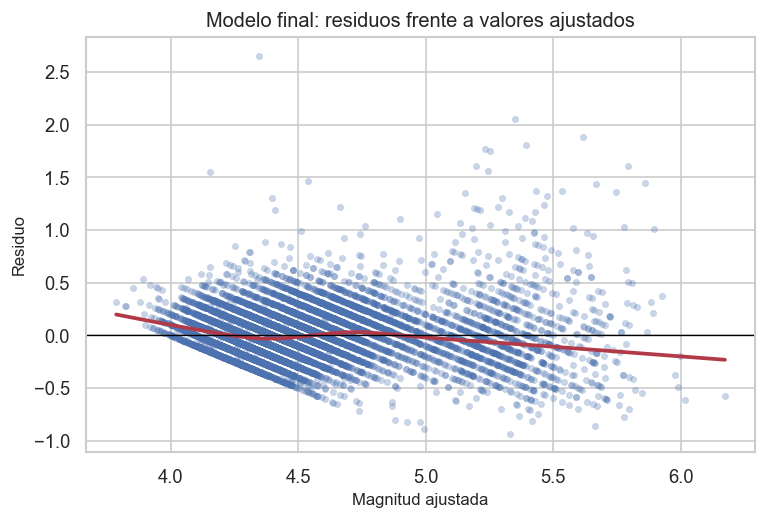

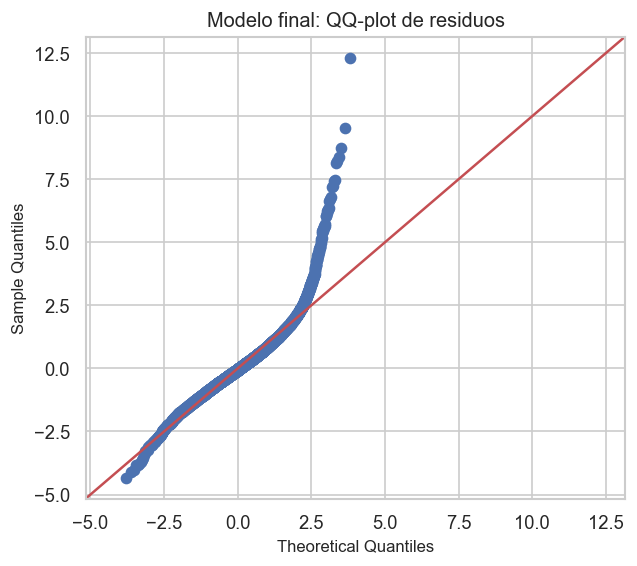

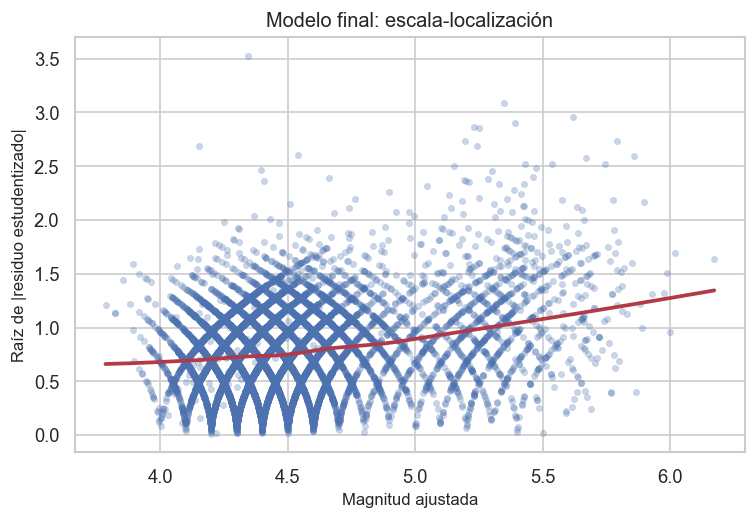

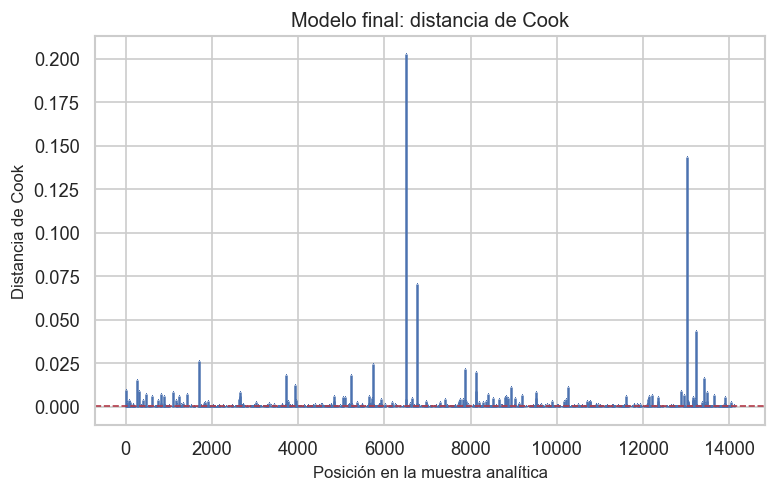

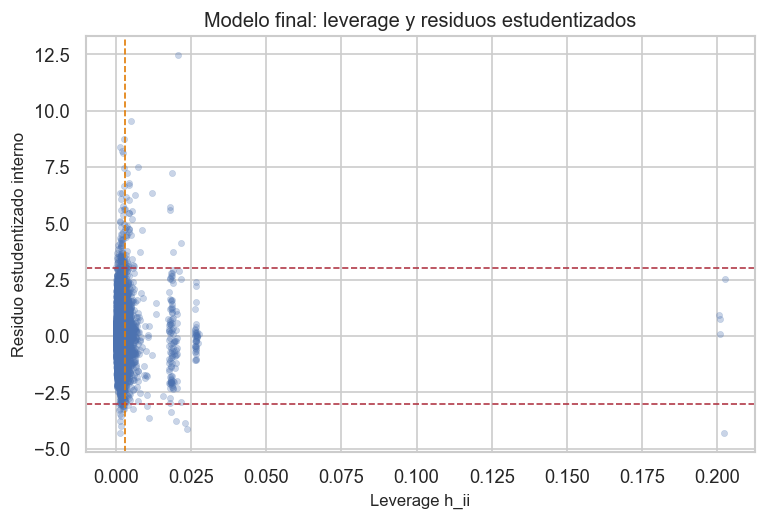

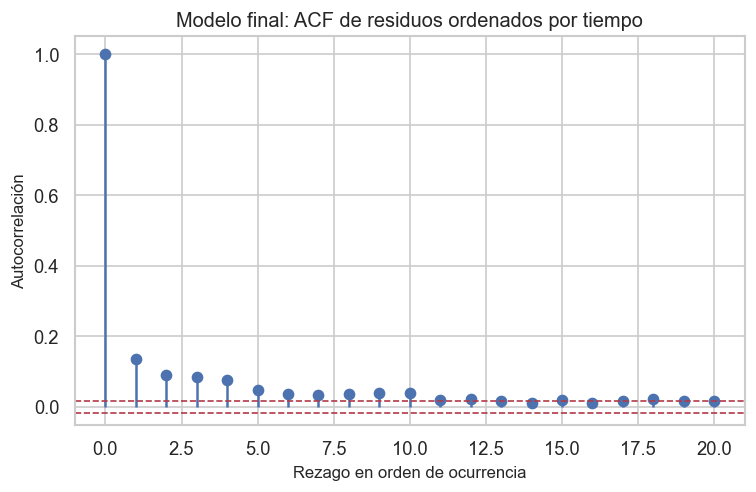

In [28]:
final_influence = final_fit.get_influence()
final_fitted = np.asarray(final_fit.fittedvalues)
final_resid = np.asarray(final_fit.resid)
final_internal = np.asarray(final_influence.resid_studentized_internal)
final_cooks = np.asarray(final_influence.cooks_distance[0])

plt.figure(figsize=(7.2, 4.5))
sns.scatterplot(x=final_fitted, y=final_resid, alpha=0.30, s=14, edgecolor=None)
sns.regplot(x=final_fitted, y=final_resid, scatter=False, lowess=True, color="#b23a48")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Modelo final: residuos frente a valores ajustados")
plt.xlabel("Magnitud ajustada")
plt.ylabel("Residuo")
save_current_figure("fig_final_resid_fitted")

plt.figure(figsize=(5.8, 5.0))
sm.qqplot(final_resid, line="45", fit=True, ax=plt.gca())
plt.title("Modelo final: QQ-plot de residuos")
save_current_figure("fig_final_qq")

plt.figure(figsize=(7.2, 4.5))
scale_location = np.sqrt(np.abs(final_internal))
sns.scatterplot(x=final_fitted, y=scale_location, alpha=0.30, s=14, edgecolor=None)
sns.regplot(x=final_fitted, y=scale_location, scatter=False, lowess=True, color="#b23a48")
plt.title("Modelo final: escala-localización")
plt.xlabel("Magnitud ajustada")
plt.ylabel("Raíz de |residuo estudentizado|")
save_current_figure("fig_final_scale_location")

plt.figure(figsize=(7.2, 4.2))
plt.stem(np.arange(len(final_cooks)), final_cooks, markerfmt=",", basefmt=" ")
plt.axhline(4 / len(final_cooks), color="#b23a48", linestyle="--", linewidth=1)
plt.title("Modelo final: distancia de Cook")
plt.xlabel("Posición en la muestra analítica")
plt.ylabel("Distancia de Cook")
save_current_figure("fig_final_cooks")

plt.figure(figsize=(7.2, 4.5))
sns.scatterplot(x=h_final, y=final_internal, alpha=0.30, s=14, edgecolor=None)
plt.axhline(3, color="#b23a48", linestyle="--", linewidth=1)
plt.axhline(-3, color="#b23a48", linestyle="--", linewidth=1)
plt.axvline(2 * p_final / len(h_final), color="#E17C05", linestyle="--", linewidth=1)
plt.title("Modelo final: leverage y residuos estudentizados")
plt.xlabel("Leverage h_ii")
plt.ylabel("Residuo estudentizado interno")
save_current_figure("fig_final_leverage")

time_order = final_model_data.loc[final_fit.model.data.row_labels].sort_values("time").index
ordered_resid = pd.Series(final_resid, index=final_fit.model.data.row_labels).loc[time_order].values
acf_values = acf(ordered_resid, nlags=20, fft=True)
plt.figure(figsize=(7.2, 4.2))
plt.stem(range(len(acf_values)), acf_values, basefmt=" ")
plt.axhline(1.96 / np.sqrt(len(ordered_resid)), color="#b23a48", linestyle="--", linewidth=1)
plt.axhline(-1.96 / np.sqrt(len(ordered_resid)), color="#b23a48", linestyle="--", linewidth=1)
plt.title("Modelo final: ACF de residuos ordenados por tiempo")
plt.xlabel("Rezago en orden de ocurrencia")
plt.ylabel("Autocorrelación")
save_current_figure("fig_final_acf")

In [29]:
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(final_resid, X_final)
white_lm, white_lm_p, white_f, white_f_p = het_white(final_resid, X_final)
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(final_resid)
rng = np.random.default_rng(2307)
shapiro_sample = rng.choice(final_resid, size=min(5000, len(final_resid)), replace=False)
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)
reset_final = linear_reset(final_fit, power=2, use_f=True)
dw_final = durbin_watson(ordered_resid)
ljung_box_10 = acorr_ljungbox(ordered_resid, lags=[10], return_df=True).iloc[0]

final_diagnostics_raw = pd.DataFrame([
    {"Prueba": "F global", "H0": "Todas las pendientes son cero", "Estadístico": final_fit.fvalue, "p-valor": final_fit.f_pvalue},
    {"Prueba": "Breusch-Pagan", "H0": "Varianza constante (forma lineal)", "Estadístico": bp_lm, "p-valor": bp_lm_p},
    {"Prueba": "White", "H0": "Varianza constante (forma general)", "Estadístico": white_lm, "p-valor": white_lm_p},
    {"Prueba": "Jarque-Bera", "H0": "Normalidad residual", "Estadístico": jb_stat, "p-valor": jb_p},
    {"Prueba": "Shapiro-Wilk (n=5000)", "H0": "Normalidad residual", "Estadístico": shapiro_stat, "p-valor": shapiro_p},
    {"Prueba": "Ramsey RESET", "H0": "Forma funcional adecuada", "Estadístico": float(np.asarray(reset_final.fvalue).squeeze()), "p-valor": float(np.asarray(reset_final.pvalue).squeeze())},
    {"Prueba": "Durbin-Watson", "H0": "Sin autocorrelación de primer orden", "Estadístico": dw_final, "p-valor": np.nan},
    {"Prueba": "Ljung-Box (10 rezagos)", "H0": "Autocorrelaciones 1--10 iguales a cero", "Estadístico": float(ljung_box_10["lb_stat"]), "p-valor": float(ljung_box_10["lb_pvalue"])},
])
final_diagnostics = final_diagnostics_raw.copy()
final_diagnostics["Estadístico"] = final_diagnostics["Estadístico"].map(lambda x: f"{x:.3f}")
final_diagnostics["p-valor"] = final_diagnostics["p-valor"].map(lambda x: "--" if pd.isna(x) else format_pvalue(x))
final_diagnostics.to_csv(REPORT_TABLE_DIR / "final_diagnostic_tests.csv", index=False)
write_latex_tabular(final_diagnostics, REPORT_TABLE_DIR / "final_diagnostic_tests.tex", column_format="llrr")

assumption_summary = pd.DataFrame([
    {"Supuesto": "A1: media bien especificada", "Evidencia": "Lineal en beta; RESET rechaza", "Conclusión y acción": "Cumplimiento parcial; cuadrados/interacciones y validación"},
    {"Supuesto": "A2: rango completo", "Evidencia": f"rank(X)={rank_x}=p", "Conclusión y acción": "Identificable; revisar VIF y condición"},
    {"Supuesto": "A3: E(error|X)=0", "Evidencia": "No comprobable con datos observacionales", "Conclusión y acción": "No interpretar causalmente; reconocer omisión/error de medición"},
    {"Supuesto": "A4: varianza/dependencia", "Evidencia": "BP y White rechazan; DW/ACF y Ljung-Box sugieren dependencia", "Conclusión y acción": "HC3 principal; clúster por región y validación espacial"},
    {"Supuesto": "A5: normalidad", "Evidencia": "JB y Shapiro-Wilk rechazan", "Conclusión y acción": "Inferencia exacta clásica no se sostiene; gran n y robustez"},
])
assumption_summary.to_csv(REPORT_TABLE_DIR / "assumption_summary.csv", index=False)
write_latex_tabular(
    assumption_summary,
    REPORT_TABLE_DIR / "assumption_summary.tex",
    column_format="@{}p{0.22\\textwidth}p{0.29\\textwidth}p{0.43\\textwidth}@{}",
)

display(final_diagnostics)
display(assumption_summary)

,Prueba,H0,Estadístico,p-valor
0,F global,Todas las pendientes son cero,1312.949,<0.001
1,Breusch-Pagan,Varianza constante (forma lineal),1566.812,<0.001
2,White,Varianza constante (forma general),3024.538,<0.001
3,Jarque-Bera,Normalidad residual,32276.230,<0.001
4,Shapiro-Wilk (n=5000),Normalidad residual,0.947,<0.001
5,Ramsey RESET,Forma funcional adecuada,22.656,<0.001
6,Durbin-Watson,Sin autocorrelación de primer orden,1.731,--
7,Ljung-Box (10 rezagos),Autocorrelaciones 1--10 iguales a cero,679.556,<0.001


,Supuesto,Evidencia,Conclusión y acción
0,A1: media bien especificada,Lineal en beta; RESET rechaza,Cumplimiento parcial; cuadrados/interacciones ...
1,A2: rango completo,rank(X)=23=p,Identificable; revisar VIF y condición
2,A3: E(error|X)=0,No comprobable con datos observacionales,No interpretar causalmente; reconocer omisión/...
3,A4: varianza/dependencia,BP y White rechazan; DW/ACF y Ljung-Box sugier...,HC3 principal; clúster por región y validación...
4,A5: normalidad,JB y Shapiro-Wilk rechazan,Inferencia exacta clásica no se sostiene; gran...


### 5.4. Lectura de supuestos

Los tests no “certifican” que el modelo sea verdadero. A1 se cumple algebraicamente porque el modelo es lineal en $\beta$, pero RESET indica estructura media remanente. A2 está respaldado por rango completo. A3 no es verificable y excluye lenguaje causal. A4 y A5 se rechazan, por lo que la ANOVA y los tests clásicos se presentan como descomposición y referencia, mientras la inferencia principal usa HC3 y sensibilidades agrupadas por región.

Breusch-Pagan detecta varianza relacionada linealmente con los regresores; White permite una forma más general. Durbin-Watson, ACF y Ljung-Box a diez rezagos son tamizajes porque los eventos no forman una serie igualmente espaciada y el orden temporal mezcla regiones. Ljung-Box aporta un contraste conjunto formal, pero su rechazo no identifica por sí solo un proceso AR(1). La normalidad no es necesaria para calcular MCO, pero sí para resultados t/F exactos en muestras finitas.

In [30]:
n_final = int(final_fit.nobs)
df_resid = float(final_fit.df_resid)
mse_final = float(final_fit.mse_resid)
deleted_mse = (df_resid * mse_final - final_resid**2 / (1 - h_final)) / (df_resid - 1)
deleted_mse = np.maximum(deleted_mse, np.finfo(float).eps)
external_studentized = final_resid / np.sqrt(deleted_mse * (1 - h_final))
dffits = external_studentized * np.sqrt(h_final / (1 - h_final))

xtx_inv = np.linalg.inv(X_final.T @ X_final)
x_xtx_inv = X_final @ xtx_inv
delta_beta = (final_resid / (1 - h_final))[:, None] * x_xtx_inv
diag_delete = np.diag(xtx_inv)[None, :] + (x_xtx_inv**2) / (1 - h_final)[:, None]
dfbetas = delta_beta / np.sqrt(deleted_mse[:, None] * diag_delete)
max_abs_dfbetas = np.max(np.abs(dfbetas), axis=1)
covratio = (deleted_mse / mse_final) ** p_final / (1 - h_final)

thresholds = {
    "Leverage > 2p/n": h_final > 2 * p_final / n_final,
    "Cook > 4/n": final_cooks > 4 / n_final,
    "|Residuo externo| > 3": np.abs(external_studentized) > 3,
    "|DFFITS| > 2sqrt(p/n)": np.abs(dffits) > 2 * np.sqrt(p_final / n_final),
    "max |DFBETAS| > 2/sqrt(n)": max_abs_dfbetas > 2 / np.sqrt(n_final),
    "|COVRATIO-1| > 3p/n": np.abs(covratio - 1) > 3 * p_final / n_final,
}
influence_counts = pd.DataFrame([
    {"Regla orientativa": label, "Eventos señalados": int(mask.sum()), "Porcentaje": 100 * float(mask.mean())}
    for label, mask in thresholds.items()
])
influence_counts["Porcentaje"] = influence_counts["Porcentaje"].round(2)
influence_counts.to_csv(REPORT_TABLE_DIR / "final_influence_counts.csv", index=False)
write_latex_tabular(influence_counts, REPORT_TABLE_DIR / "final_influence_counts.tex", column_format="lrr")

influence_frame = final_model_data.loc[final_fit.model.data.row_labels, ["id", "mag", "magType_grouped"]].reset_index(drop=True)
influence_frame["leverage"] = h_final
influence_frame["Cook"] = final_cooks
influence_frame["residuo externo"] = external_studentized
influence_frame["DFFITS"] = dffits
influence_frame["max |DFBETAS|"] = max_abs_dfbetas
influence_frame["COVRATIO"] = covratio
top_influence = influence_frame.nlargest(12, "Cook").copy()
top_influence.to_csv(REPORT_TABLE_DIR / "final_top_influence.csv", index=False)

# M-estimación de Huber como sensibilidad frente a observaciones extremas.
rlm_fit = sm.RLM(final_fit.model.endog, X_final, M=sm.robust.norms.HuberT()).fit(maxiter=100)
rlm_terms = ["z_depth", "I(z_depth ** 2)", "z_latitude", "z_longitude", "z_log_nst", "z_log_gap", "z_log_dmin", "z_rms"]
rlm_rows = []
for term in rlm_terms:
    idx = name_to_index[term]
    ols_value = final_fit.params.iloc[idx]
    robust_value = rlm_fit.params[idx]
    rlm_rows.append({
        "Término": term,
        "MCO": ols_value,
        "M-Huber": robust_value,
        "Cambio absoluto": robust_value - ols_value,
    })
rlm_sensitivity = pd.DataFrame(rlm_rows).round(4)
rlm_sensitivity.to_csv(REPORT_TABLE_DIR / "rlm_sensitivity.csv", index=False)
write_latex_tabular(rlm_sensitivity, REPORT_TABLE_DIR / "rlm_sensitivity.tex", column_format="lrrr")

display(influence_counts)
display(top_influence)
display(rlm_sensitivity)

,Regla orientativa,Eventos señalados,Porcentaje
0,Leverage > 2p/n,907,6.42
1,Cook > 4/n,739,5.23
2,|Residuo externo| > 3,147,1.04
3,|DFFITS| > 2sqrt(p/n),740,5.24
4,max |DFBETAS| > 2/sqrt(n),4051,28.68
5,|COVRATIO-1| > 3p/n,885,6.27


,id,mag,magType_grouped,leverage,Cook,residuo externo,DFFITS,max |DFBETAS|,COVRATIO
6493,hv74260121,4.10,Other,0.202199,0.202588,-4.290393,-2.159927,1.917871,1.218378
13031,nc75095651,7.00,mw,0.020854,0.143519,12.518020,1.826849,1.510785,0.793346
6747,us7000mrbq,5.70,Other,0.202491,0.070767,2.532366,1.276031,1.130825,1.242884
13227,nn00888580,5.70,mw,0.018671,0.043400,7.256574,1.000929,0.910050,0.936826
1709,hv74103036,5.88,ml,0.018218,0.026221,5.707398,0.777457,0.719377,0.967483
5737,pr2024136000,5.60,ml,0.018049,0.024889,5.586710,0.757415,0.730738,0.969465
7871,us7000myfa,7.10,mww,0.012195,0.021512,6.339434,0.704383,0.347853,0.949746
8124,us7000n05d,7.40,mww,0.004971,0.019795,9.576612,0.676914,0.445272,0.867187
5216,ci40735352,4.11,mw,0.023861,0.018314,-4.153523,-0.649386,0.464942,0.997660
3707,us7000m9g4,7.40,mww,0.007338,0.018022,7.503003,0.645075,0.279568,0.920673


,Término,MCO,M-Huber,Cambio absoluto
0,z_depth,-0.1597,-0.1598,-0.0001
1,I(z_depth ** 2),0.0271,0.0267,-0.0004
2,z_latitude,-0.0966,-0.0987,-0.0021
3,z_longitude,0.0418,0.0414,-0.0004
4,z_log_nst,0.1894,0.1892,-0.0002
5,z_log_gap,-0.0370,-0.0356,0.0014
6,z_log_dmin,0.0269,0.0301,0.0031
7,z_rms,0.0115,0.0086,-0.0028


Los umbrales de influencia son reglas de revisión, no criterios de borrado. Eliminar automáticamente sismos grandes o profundos cambiaría la población de interés. La M-estimación de Huber se usa como sensibilidad: si los signos y órdenes de magnitud de los efectos principales permanecen, la conclusión no depende exclusivamente de unos pocos residuos grandes. MCO+HC3 sigue siendo principal porque la pregunta se formula sobre la media condicional y se requiere inferencia transparente.

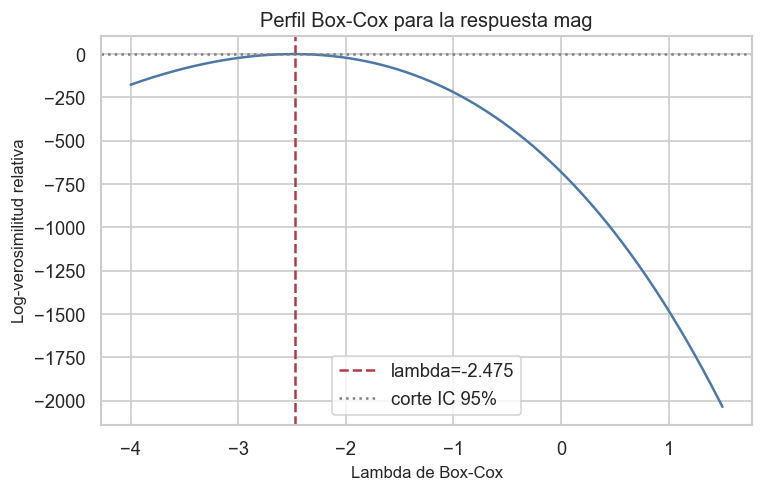

,Condición de positividad,lambda perfil,IC 95% inferior,IC 95% superior,Decisión
0,Cumplida: mag >= 4,-2.475,-2.625,-2.35,"No adoptar: truncamiento, interpretación y sup..."


,Transformación,lambda,BP p-valor,RESET p-valor,JB p-valor
0,Identidad,1.000,<0.001,<0.001,<0.001
1,Raíz,0.500,<0.001,0.006,<0.001
2,Log,0.000,<0.001,0.346,<0.001
3,Perfil,-2.475,<0.001,<0.001,<0.001


,Alternativa,RMSE en mag,BP p-valor,Uso
0,MCO final + HC3,0.2153,<0.001,Principal
1,WLS por varianza estimada,0.2156,<0.001,Sensibilidad; heterocedasticidad persiste


In [31]:
# Box-Cox de la respuesta: perfil de verosimilitud con jacobiano.
if (final_model_data["mag"] <= 0).any():
    raise ValueError("Box-Cox requiere respuesta estrictamente positiva.")

def boxcox_transform(values, lam):
    values = np.asarray(values)
    if abs(lam) < 1e-8:
        return np.log(values)
    return (values**lam - 1) / lam

lambda_grid = np.linspace(-4, 1.5, 221)
sum_log_y = float(np.log(y_final).sum())
profile_ll = []
for lam in lambda_grid:
    transformed = boxcox_transform(y_final, lam)
    beta_lam = np.linalg.lstsq(X_final, transformed, rcond=None)[0]
    residual_lam = transformed - X_final @ beta_lam
    sse_lam = float(np.sum(residual_lam**2))
    profile_ll.append(-n_final / 2 * np.log(sse_lam / n_final) + (lam - 1) * sum_log_y)
profile_ll = np.asarray(profile_ll)
best_idx = int(np.argmax(profile_ll))
lambda_hat = float(lambda_grid[best_idx])
cutoff = profile_ll[best_idx] - stats.chi2.ppf(0.95, 1) / 2
lambda_ci_values = lambda_grid[profile_ll >= cutoff]
lambda_ci = (float(lambda_ci_values.min()), float(lambda_ci_values.max()))

plt.figure(figsize=(7.0, 4.2))
plt.plot(lambda_grid, profile_ll - profile_ll.max(), color="#4C78A8")
plt.axvline(lambda_hat, color="#b23a48", linestyle="--", label=f"lambda={lambda_hat:.3f}")
plt.axhline(-stats.chi2.ppf(0.95, 1) / 2, color="gray", linestyle=":", label="corte IC 95%")
plt.xlabel("Lambda de Box-Cox")
plt.ylabel("Log-verosimilitud relativa")
plt.title("Perfil Box-Cox para la respuesta mag")
plt.legend()
save_current_figure("fig_boxcox_profile")

response_rows = []
for label, lam in [("Identidad", 1.0), ("Raíz", 0.5), ("Log", 0.0), ("Perfil", lambda_hat)]:
    transformed = boxcox_transform(y_final, lam)
    fit_lam = sm.OLS(transformed, X_final).fit()
    bp_lam = het_breuschpagan(fit_lam.resid, X_final)
    reset_lam = linear_reset(fit_lam, power=2, use_f=True)
    jb_lam = jarque_bera(fit_lam.resid)
    response_rows.append({
        "Transformación": label,
        "lambda": lam,
        "BP p-valor": bp_lam[1],
        "RESET p-valor": float(np.asarray(reset_lam.pvalue).squeeze()),
        "JB p-valor": jb_lam[1],
    })
response_transform_sensitivity = pd.DataFrame(response_rows)
response_transform_display = response_transform_sensitivity.copy()
response_transform_display["lambda"] = response_transform_display["lambda"].round(3)
for col in ["BP p-valor", "RESET p-valor", "JB p-valor"]:
    response_transform_display[col] = response_transform_display[col].map(format_pvalue)
response_transform_display.to_csv(REPORT_TABLE_DIR / "response_transform_sensitivity.csv", index=False)
write_latex_tabular(response_transform_display, REPORT_TABLE_DIR / "response_transform_sensitivity.tex", column_format="lrrrr")

boxcox_summary = pd.DataFrame([{
    "Condición de positividad": "Cumplida: mag >= 4",
    "lambda perfil": lambda_hat,
    "IC 95% inferior": lambda_ci[0],
    "IC 95% superior": lambda_ci[1],
    "Decisión": "No adoptar: truncamiento, interpretación y supuestos residuales",
}]).round(3)
boxcox_summary.to_csv(REPORT_TABLE_DIR / "boxcox_summary.csv", index=False)

# WLS como sensibilidad, no como reemplazo automático.
variance_data = pd.DataFrame({"log_resid_sq": np.log(final_resid**2 + 1e-8), "fitted": final_fitted})
variance_data["fitted_sq"] = variance_data["fitted"] ** 2
variance_fit = smf.ols("log_resid_sq ~ fitted + fitted_sq", data=variance_data).fit()
predicted_variance = np.exp(variance_fit.predict(variance_data))
weights = 1 / np.clip(predicted_variance, np.quantile(predicted_variance, 0.01), np.quantile(predicted_variance, 0.99))
wls_fit = smf.wls(gfinal_formula, data=final_model_data, weights=weights).fit()
wls_standardized_resid = np.sqrt(weights) * np.asarray(wls_fit.resid)
wls_bp = het_breuschpagan(wls_standardized_resid, np.asarray(wls_fit.model.exog))

remedy_display = pd.DataFrame([
    {"Alternativa": "MCO final + HC3", "RMSE en mag": np.sqrt(np.mean(final_resid**2)), "BP p-valor": format_pvalue(bp_lm_p), "Uso": "Principal"},
    {"Alternativa": "WLS por varianza estimada", "RMSE en mag": np.sqrt(np.mean(np.asarray(wls_fit.resid)**2)), "BP p-valor": format_pvalue(wls_bp[1]), "Uso": "Sensibilidad; heterocedasticidad persiste"},
])
remedy_display["RMSE en mag"] = remedy_display["RMSE en mag"].round(4)
remedy_display.to_csv(REPORT_TABLE_DIR / "final_remedy_sensitivity.csv", index=False)
write_latex_tabular(remedy_display, REPORT_TABLE_DIR / "final_remedy_sensitivity.tex", column_format="lrrl")

display(boxcox_summary)
display(response_transform_display)
display(remedy_display)

### 5.5. Box-Cox, WLS y decisiones no adoptadas

Box-Cox requiere una respuesta estrictamente positiva, condición satisfecha porque `mag >= 4`. El perfil se calcula para el modelo completo y añade el jacobiano $(\lambda-1)\sum\log y_i$; por eso sí permite comparar lambdas, a diferencia de comparar $R^2$ de respuestas distintas. Sin embargo, el perfil está condicionado a un modelo normal homocedástico y a una muestra no truncada en la interpretación usual. Aquí la acumulación artificial en 4 influye en $\lambda$, la magnitud ya posee significado logarítmico y los tests residuales continúan rechazando tras transformar. Adoptar Box-Cox exigiría además retransformación con corrección de sesgo. Se conserva `mag` por claridad sustantiva y se usa HC3.

WLS solo sería preferible si una función de varianza defendible redujera la heterocedasticidad y mejorara eficiencia. La varianza estimada deja evidencia residual de heterocedasticidad y no mejora el error en escala de magnitud; se reporta como sensibilidad, no como modelo final.

Ridge y Lasso no se adoptan: no hay deficiencia de rango y la colinealidad moderada se concentra en el polinomio de profundidad. Penalizar sesgaría coeficientes cuya interpretación es central. Tampoco se usa IV/2SLS porque no existe un instrumento con relevancia y exogeneidad defendibles.

In [32]:
def evaluate_splits(split_iterator, scheme):
    rows = []
    for fold, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        train_raw = final_raw.iloc[train_idx].copy()
        test_raw = final_raw.iloc[test_idx].copy()
        train_ready, test_ready = prepare_train_test(train_raw, test_raw)
        for model_name, model_formula in [("M4 base", g0_formula), ("G final", gfinal_formula)]:
            fold_fit = smf.ols(model_formula, data=train_ready).fit()
            prediction = fold_fit.predict(test_ready)
            rows.append({
                "Esquema": scheme,
                "Pliegue": fold,
                "Modelo": model_name,
                "RMSE": np.sqrt(mean_squared_error(test_ready["mag"], prediction)),
                "MAE": mean_absolute_error(test_ready["mag"], prediction),
                "R2": r2_score(test_ready["mag"], prediction),
            })
    return rows

validation_rows = evaluate_splits(
    KFold(n_splits=5, shuffle=True, random_state=2307).split(final_raw), "CV aleatoria 5-fold"
)
group_labels = final_raw["region_grouped"].astype(str).fillna("Missing")
validation_rows += evaluate_splits(
    GroupKFold(n_splits=5).split(final_raw, groups=group_labels), "CV por región 5-fold"
)
ordered_positions = np.argsort(pd.to_datetime(final_raw["time"], utc=True).values)
cut = int(0.8 * len(ordered_positions))
validation_rows += evaluate_splits([(ordered_positions[:cut], ordered_positions[cut:])], "Corte temporal 80/20")

validation_folds = pd.DataFrame(validation_rows)
validation_summary = validation_folds.groupby(["Esquema", "Modelo"], as_index=False).agg(
    RMSE=("RMSE", "mean"), MAE=("MAE", "mean"), R2=("R2", "mean"),
    SD_RMSE=("RMSE", "std"), SD_R2=("R2", "std")
).fillna(0).round(4)
validation_folds.to_csv(REPORT_TABLE_DIR / "final_validation_folds.csv", index=False)
validation_summary.to_csv(REPORT_TABLE_DIR / "final_validation_summary.csv", index=False)
write_latex_tabular(validation_summary, REPORT_TABLE_DIR / "final_validation_summary.tex", column_format="llrrrrr")
display(validation_summary)

,Esquema,Modelo,RMSE,MAE,R2,SD_RMSE,SD_R2
0,CV aleatoria 5-fold,G final,0.2161,0.1585,0.6693,0.0042,0.0024
1,CV aleatoria 5-fold,M4 base,0.2312,0.1708,0.6216,0.0051,0.0107
2,CV por región 5-fold,G final,0.2252,0.1653,0.6329,0.0239,0.0637
3,CV por región 5-fold,M4 base,0.2360,0.1741,0.5967,0.0221,0.0655
4,Corte temporal 80/20,G final,0.2259,0.1630,0.6385,0.0000,0.0000
5,Corte temporal 80/20,M4 base,0.2370,0.1743,0.6022,0.0000,0.0000


### 5.6. Validación, predicción e incertidumbre

La validación aleatoria estima estabilidad dentro del catálogo; la validación por región exige transferir el modelo a zonas no usadas en el ajuste; y el corte temporal evalúa el último 20% de 2024. Las transformaciones y estandarizaciones se calculan solo con entrenamiento para evitar filtración.

El análisis es descriptivo-explicativo. Un intervalo para la media condicional describe incertidumbre de una magnitud promedio ajustada; un intervalo de predicción individual sería más ancho y, bajo heterocedasticidad, no debe construirse con una varianza constante ingenua. Además, las covariables técnicas se conocen después del registro del evento. Por ello no se presenta el modelo como anticipación de terremotos.

La selección y la inferencia usan la misma muestra, de modo que algunos p-valores pueden ser optimistas después de explorar especificaciones. Se mitiga con bloques sustantivos predefinidos, jerarquía, HC3, Bonferroni y validación separada; no se elimina por completo sin una muestra externa.

### 5.7. Conclusión estadística

Dentro de los eventos USGS 2024 con magnitud al menos 4, la magnitud reportada se asocia con profundidad, ubicación, cobertura técnica y tipo de magnitud. La relación con profundidad se representa mejor mediante un término cuadrático en escala original que mediante el log lineal inicialmente propuesto. Curvatura espacial e interacciones seleccionadas mejoran ajuste y estabilidad, pero RESET, heterocedasticidad, no normalidad y dependencia residual impiden presentar la especificación como verdad física.

La recomendación es usar el modelo para describir comparaciones ajustadas y orientar revisiones del catálogo por región y método de magnitud. No se usa para alertas, causalidad ni predicción operacional. Una extensión futura requeriría estructura espacial-temporal y modelos explícitos de error de medición con información adicional.

## 6. Reproducibilidad


El notebook genera la base procesada, las tablas y las figuras usadas por el informe LaTeX. También se guardan archivos con versiones de paquetes y una guía de ejecución.


In [33]:
packages = ["pandas", "numpy", "matplotlib", "seaborn", "statsmodels", "scipy", "scikit-learn", "nbformat", "nbclient"]
version_rows = []
for package in packages:
    try:
        version_rows.append((package, md.version(package)))
    except md.PackageNotFoundError:
        version_rows.append((package, "No instalado"))

session_lines = [
    f"Python: {sys.version.split()[0]}",
    f"Ruta relativa de datos: {RAW_DATA_PATH.relative_to(PROJECT_DIR)}",
    "Figuras del informe: Final/Plantilla_informe/figures/",
    "Tablas del informe: Final/Plantilla_informe/tables/",
    "",
    "Paquetes principales:",
]
session_lines += [f"{package}: {version}" for package, version in version_rows]
(FINAL_DIR / "session_info.txt").write_text("\n".join(session_lines) + "\n", encoding="utf-8")

requirements_text = "\n".join(
    f"{package}=={version}" for package, version in version_rows if version != "No instalado"
) + "\n"
(FINAL_DIR / "requirements.txt").write_text(requirements_text, encoding="utf-8")

readme_text = """# Proyecto de Regresión: USGS Earthquakes 2024

Este proyecto analiza, con enfoque descriptivo-explicativo, cómo se asocia la magnitud reportada de eventos sísmicos USGS durante 2024 con profundidad, localización y características técnicas del registro.

## Fuente y alcance

- Fuente: U.S. Geological Survey, Earthquake Catalog API.
- Periodo: eventos registrados durante 2024.
- Filtro metodológico: magnitud al menos 4.
- Unidad de observación: evento sísmico.

## Ejecución

Se recomienda un entorno Python 3.13 con las versiones fijadas en `requirements.txt`:

    python3.13 -m venv .venv
    source .venv/bin/activate
    python -m pip install -r requirements.txt

1. Abrir `avance_proyecto_corregido.ipynb` desde `Final/` o desde la raíz del proyecto.
2. Ejecutar todas las celdas en orden.
3. El notebook genera la base procesada, figuras, tablas, pruebas, diagnósticos y validaciones.

## Estructura

- `avance_proyecto_corregido.ipynb`: limpieza, EDA, modelos e inferencia.
- `usgs_earthquakes_2024_mag4_raw.csv`: datos crudos.
- `usgs_earthquakes_2024_mag4_model_ready.csv`: base procesada.
- `outputs/`: copias de trabajo.
- `Plantilla_informe/main.tex`: informe LaTeX.
- `Plantilla_informe/figures/` y `Plantilla_informe/tables/`: insumos generados por el notebook.

## Compilación

Desde `Final/Plantilla_informe/`:

    latexmk -C
    latexmk -xelatex -interaction=nonstopmode -file-line-error main.tex

Repositorio: https://github.com/Paul0112/proyecto_regresion

El análisis no busca predecir terremotos futuros ni emitir alertas. Las conclusiones corresponden a asociaciones dentro de la muestra truncada a magnitud mayor o igual a 4.
"""
(FINAL_DIR / "README.md").write_text(readme_text, encoding="utf-8")

session_df = pd.DataFrame(version_rows, columns=["paquete", "versión"])
display(session_df)
print(f"Archivos reproducibles guardados en {FINAL_DIR.relative_to(PROJECT_DIR)}")


,paquete,versión
0,pandas,2.2.2
1,numpy,1.26.4
2,matplotlib,3.9.1
3,seaborn,0.13.2
4,statsmodels,0.14.5
5,scipy,1.14.1
6,scikit-learn,1.6.1
7,nbformat,5.10.4
8,nbclient,0.10.0


Archivos reproducibles guardados en Final


## 7. Referencias


- U.S. Geological Survey (USGS). (2024). *Earthquake Catalog*. https://earthquake.usgs.gov/earthquakes/search/
- Montgomery, D. C., Peck, E. A., & Vining, G. G. (2021). *Introduction to Linear Regression Analysis* (6th ed.). Wiley.
- Box, G. E. P., & Cox, D. R. (1964). An analysis of transformations. *Journal of the Royal Statistical Society: Series B*, 26(2), 211-252.
- White, H. (1980). A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity. *Econometrica*, 48(4), 817-838.
- Huber, P. J. (1964). Robust estimation of a location parameter. *The Annals of Mathematical Statistics*, 35(1), 73-101.
- Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time series models. *Biometrika*, 65(2), 297-303.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
